# LOFO Class Balance Analysis

`04_cross_dataset_training.py --mode lofo` holds out one **entire dataset** per fold
and trains on the rest combined. Unlike `--mode kfold`/`random_split` (which
well-stratify -- see `build_well_stratified_nfold_splits`), LOFO can't rebalance
classes across folds at all: the held-out dataset's class composition *is* the test
set, and whatever's left over *is* the training pool for that fold. If the four
datasets in a group don't have similar class compositions, some LOFO folds will
train on a very different class balance than others (or than the held-out test set),
which can look like "the model doesn't generalize" when it's really "fold 3's
training pool is 80% one class."

This notebook:
1. Counts records per label per dataset, with `config.EXCLUDE_WELL_MAPPING` applied
   (mirrors what `03_main_training.py`/`04_cross_dataset_training.py` actually train
   on, not the raw unfiltered data).
2. Quantifies how imbalanced each LOFO fold's training pool actually is.
3. Explains why naive random over/under-sampling is unsafe for
   `cnn_gru_dual_attn_recon`/`cnn_gru_dual_cosine_recon` (they reconstruct each
   pixel's curve from its spatial neighbours *within the same well*), and
   implements well-level balancing instead, which is safe.

All data loading reuses `04_cross_dataset_training.py`'s own `load_curve_data`/
`combine_group`/`build_lofo_splits` (imported as a module) rather than
reimplementing them, so this notebook always reflects exactly what the real
training run sees -- including `EXCLUDE_WELL_MAPPING` and `LABEL_MAPPINGS`.


In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import os

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(os.path.dirname(notebook_path))
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

# Reuse 04's own data-loading/split logic instead of reimplementing it, so this
# notebook always matches what the real training run actually sees (EXCLUDE_WELL_MAPPING,
# LABEL_MAPPINGS, curve resampling, well_id construction, LOFO fold definition, ...).
cdt = importlib.import_module("04_cross_dataset_training")
# cdt's own imports already put utils/model_training on sys.path.
from model_utils import build_neighbor_curve_stack

%matplotlib inline


Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main

[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Configuration

In [3]:
GROUP_NAME  = "final_4_chip_clean"           # key into config.CROSS_DATASET_GROUPS
EXP_FOLDER  = config.FINAL_EXP_FOLDER + "_nc_subtract"
CURVE_TYPE  = "ori_curve_wavelet_bior35_norm"                     # matches 06b's default first curve type
K_NEIGHBORS = 24                              # matches 04's --k_neighbors default

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]

print(f"Group '{GROUP_NAME}' -> {len(folder_names)} datasets:")
for n in folder_names:
    print(" -", n)


Group 'final_4_chip_clean' -> 4 datasets:
 - D20260806_E00_C00_F4500KHz_U_DDM_01_06
 - D20260807_E00_C00_F4500KHz_U_DDM_02_07
 - D20260808_E00_C00_F4500KHz_U_DDM_03_01
 - D20260810_E00_C00_F4500KHz_U_DDM_04_01


In [4]:
print("EXCLUDE_WELL_MAPPING entries relevant to this group:")
for name in folder_names:
    excluded = config.EXCLUDE_WELL_MAPPING.get(name, [])
    if not excluded:
        print(f"  {name}: (none excluded)")
        continue
    label_map = config.get_label_mappings(Path(EXP_FOLDER, name)).get(name, {})
    print(f"  {name}: wells {excluded} -> labels {[label_map.get(w, '?') for w in excluded]}")


EXCLUDE_WELL_MAPPING entries relevant to this group:
  D20260806_E00_C00_F4500KHz_U_DDM_01_06: wells [8] -> labels ['PC']
  D20260807_E00_C00_F4500KHz_U_DDM_02_07: wells [6, 7, 8] -> labels ['Cov', 'Hadv', 'PC']
  D20260808_E00_C00_F4500KHz_U_DDM_03_01: wells [6, 8] -> labels ['Cov', 'PC']
  D20260810_E00_C00_F4500KHz_U_DDM_04_01: wells [8] -> labels ['PC']


## 2. Per-dataset label counts (`EXCLUDE_WELL_MAPPING` applied)

Reuses `cdt.load_curve_data(exp_path, curve_type)` -- the exact function
`combine_group`/LOFO training calls per dataset -- which already applies
`config.apply_well_exclusion` and the nc_subtract-aware `config.get_label_mappings`.
To also show the "before exclusion" counts for comparison, `EXCLUDE_WELL_MAPPING` is
temporarily cleared and restored around a second load (same dict object, so no other
cell/state is affected).

In [5]:
def label_counts_for_exp(exp_path, curve_type, apply_exclusion=True):
    """Per-label sample counts for one dataset, using cdt.load_curve_data so this
    always matches what the real training run sees. Uses LOFO_EXCLUDE_WELL_MAPPING
    (group-scoped), not the flat EXCLUDE_WELL_MAPPING -- see
    config.apply_well_exclusion's docstring."""
    saved = dict(config.LOFO_EXCLUDE_WELL_MAPPING)
    if not apply_exclusion:
        config.LOFO_EXCLUDE_WELL_MAPPING.clear()
    try:
        d = cdt.load_curve_data(exp_path, curve_type, group_name=GROUP_NAME)
    finally:
        config.LOFO_EXCLUDE_WELL_MAPPING.clear()
        config.LOFO_EXCLUDE_WELL_MAPPING.update(saved)
    if d is None:
        return None
    labels, counts = np.unique(d["Y_mapped"], return_counts=True)
    return dict(zip(labels, counts))


after_rows, before_rows = {}, {}
for exp_path in exp_paths:
    after = label_counts_for_exp(exp_path, CURVE_TYPE, apply_exclusion=True)
    before = label_counts_for_exp(exp_path, CURVE_TYPE, apply_exclusion=False)
    if after is None:
        print(f"  [!] Could not load {exp_path.name} (curve_type={CURVE_TYPE}) -- skipping.")
        continue
    after_rows[exp_path.name] = after
    before_rows[exp_path.name] = before


  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] EXCLUDE_WELL_MAPPING: dropping 3745 samples from wells [6, 7, 8] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] EXCLUDE_WELL_MAPPING: dropping 1928 samples from wells [6, 8] (y_label={6: 'Cov', 8: 'PC'}, y_concentration={6: '1e+04', 8: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01


In [6]:
after_table  = pd.DataFrame(after_rows).fillna(0).astype(int).T
before_table = pd.DataFrame(before_rows).fillna(0).astype(int).T

dropped_total = before_table.sum(axis=1) - after_table.sum(axis=1)
print("Samples dropped by EXCLUDE_WELL_MAPPING, per dataset:")
print(dropped_total[dropped_total > 0].to_string() if (dropped_total > 0).any() else "  (none)")

print("\nPer-dataset label counts (after EXCLUDE_WELL_MAPPING):")
after_table


Samples dropped by EXCLUDE_WELL_MAPPING, per dataset:
D20260807_E00_C00_F4500KHz_U_DDM_02_07    3745
D20260808_E00_C00_F4500KHz_U_DDM_03_01    1928

Per-dataset label counts (after EXCLUDE_WELL_MAPPING):


,Cov,Hadv,IAV,IBV,Kp,NC
D20260806_E00_C00_F4500KHz_U_DDM_01_06,1848,1919,5777,1907,1921,1135
D20260807_E00_C00_F4500KHz_U_DDM_02_07,0,0,3671,4315,1911,1778
D20260808_E00_C00_F4500KHz_U_DDM_03_01,0,1828,1786,3755,5587,1642
D20260810_E00_C00_F4500KHz_U_DDM_04_01,5641,1943,1920,1921,3834,1315


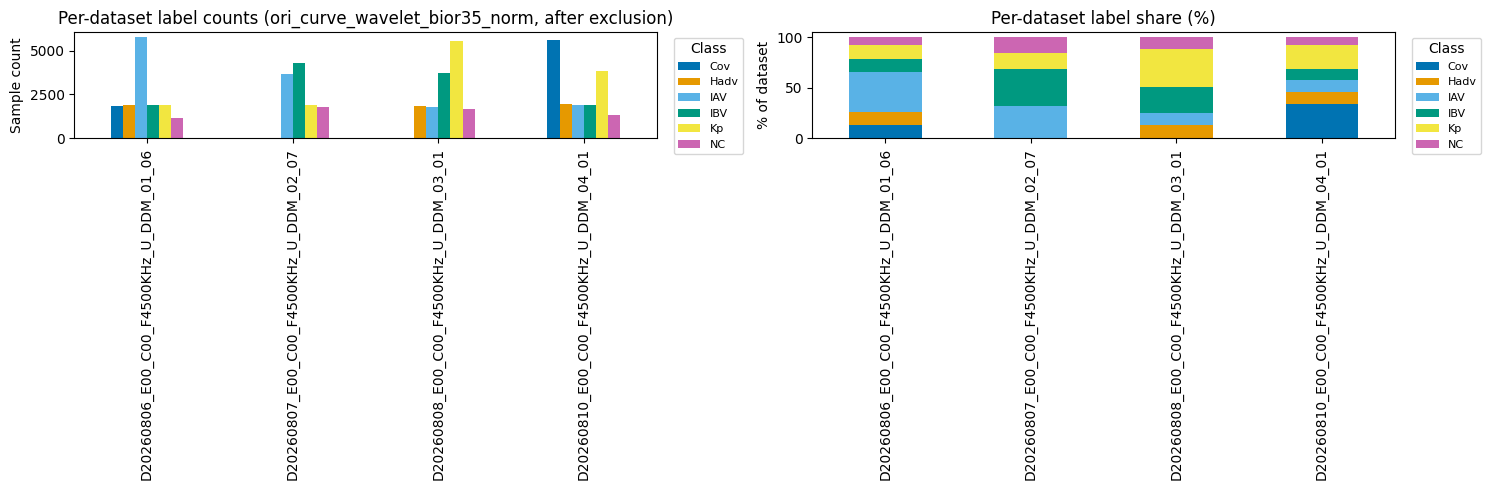

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

after_table.plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Per-dataset label counts ({CURVE_TYPE}, after exclusion)")
axes[0].set_ylabel("Sample count")
axes[0].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

after_pct = after_table.div(after_table.sum(axis=1), axis=0) * 100
after_pct.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Per-dataset label share (%)")
axes[1].set_ylabel("% of dataset")
axes[1].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


## 3. LOFO fold-level imbalance (training pool vs. held-out test set)

For each LOFO fold, the training pool is *every other dataset combined*. Two
failure modes to look for here:
- A class that's almost entirely concentrated in one dataset -> when that dataset
  is held out, the training pool barely sees that class (or vice versa: the test
  set is nearly pure in a class the model rarely trained on).
- A large `train_max_min_ratio` -> standard majority/minority class imbalance
  within that fold's training pool, independent of which fold is held out.

Uses `cdt.combine_group` (real curve resampling + concatenation, exclusion-aware)
and `cdt.build_lofo_splits` (the exact split the real LOFO run trains on).

In [8]:
combined = cdt.combine_group(exp_paths, GROUP_NAME, curve_type=CURVE_TYPE)
assert combined is not None, "combine_group returned None -- check EXP_FOLDER/GROUP_NAME/CURVE_TYPE"

has_spatial = combined["coords"] is not None and combined["well_ids"] is not None
print(f"Combined pool: {len(combined['Y_mapped'])} samples across {len(exp_paths)} datasets. "
      f"Spatial metadata available: {has_spatial}")

lofo_splits = cdt.build_lofo_splits(combined["dataset_id"])
print(f"{len(lofo_splits)} LOFO folds: {list(lofo_splits.keys())}")


  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] EXCLUDE_WELL_MAPPING: dropping 3745 samples from wells [6, 7, 8] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] EXCLUDE_WELL_MAPPING: dropping 1928 samples from wells [6, 8] (y_label={6: 'Cov', 8: 'PC'}, y_concentration={6: '1e+04', 8: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01
  [*] Resampling curves onto common grid: 733 points, duration=2081
Combined pool: 57354 samples across 4 datasets. Spatial metadata available: True
4 LOFO folds: ['lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06', 'lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07', 'lofo_D20260808_E00_C00_F4500KHz_U_DDM_0

In [9]:
fold_rows = []
for fold_label, (train_idx, test_idx) in lofo_splits.items():
    y_train = combined["Y_mapped"][train_idx]
    y_test  = combined["Y_mapped"][test_idx]
    train_counts = pd.Series(y_train).value_counts()
    test_counts  = pd.Series(y_test).value_counts()
    missing = sorted(set(test_counts.index) - set(train_counts.index))
    ratio = float(train_counts.max() / train_counts.min()) if len(train_counts) > 1 else float("nan")
    fold_rows.append({
        "fold": fold_label,
        "n_train": len(train_idx), "n_test": len(test_idx),
        "n_classes_train": len(train_counts), "n_classes_test": len(test_counts),
        "classes_missing_from_train": missing,
        "train_max_min_ratio": round(ratio, 2),
    })

fold_summary = pd.DataFrame(fold_rows).sort_values("train_max_min_ratio", ascending=False)
fold_summary


,fold,n_train,n_test,n_classes_train,n_classes_test,classes_missing_from_train,train_max_min_ratio
3,lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01,40780,16574,6,6,[],6.08
0,lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06,42847,14507,6,6,[],3.01
2,lofo_D20260808_E00_C00_F4500KHz_U_DDM_03_01,42756,14598,6,5,[],2.94
1,lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07,45679,11675,6,4,[],2.77


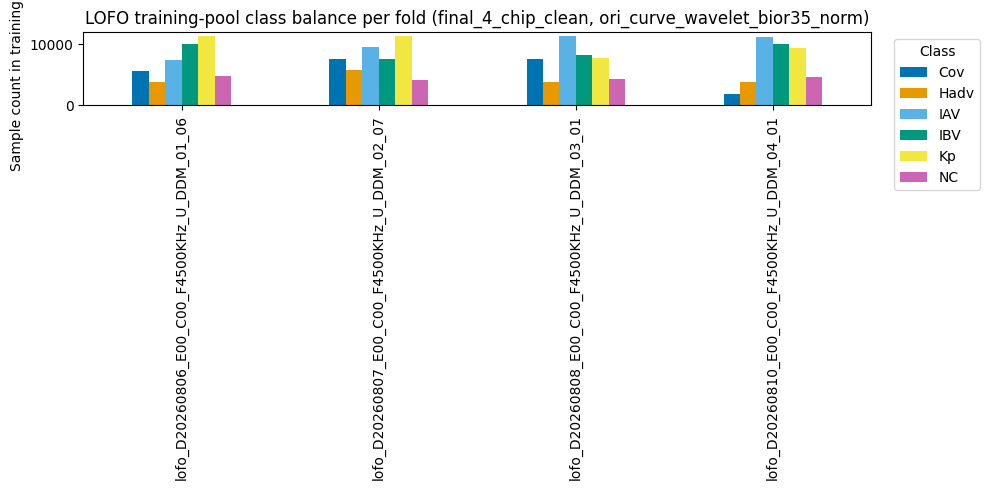

,lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06,lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07,lofo_D20260808_E00_C00_F4500KHz_U_DDM_03_01,lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01
Cov,5641,7489,7489,1848
Hadv,3771,5690,3862,3747
IAV,7377,9483,11368,11234
IBV,9991,7583,8143,9977
Kp,11332,11342,7666,9419
NC,4735,4092,4228,4555


In [10]:
train_class_table = pd.DataFrame({
    fold_label: pd.Series(combined["Y_mapped"][train_idx]).value_counts()
    for fold_label, (train_idx, _) in lofo_splits.items()
}).fillna(0).astype(int).sort_index()

ax = train_class_table.T.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Sample count in training pool")
ax.set_title(f"LOFO training-pool class balance per fold ({GROUP_NAME}, {CURVE_TYPE})")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

train_class_table


## 4. Why naive resampling breaks `attn_recon`/`cosine_recon`

`build_neighbor_curve_stack` (`utils/model_training/model_utils.py:259`) is what
`cnn_gru_dual_attn_recon`/`cnn_gru_dual_cosine_recon` use to reconstruct each pixel's
curve from its spatial neighbours. The key mechanics:

- For every well, it fits a fresh `NearestNeighbors` **within that well only**
  (`well_coords = coords[well_idx]`) and looks up each pixel's `k` nearest
  neighbours by `(pixel_row_idx, pixel_col_idx)`.
- It's called **separately per split side** -- `model_utils.py` slices
  `X_AC[train_idx]`/`coords_m[train_idx]`/`well_ids_m[train_idx]` *before* calling
  it, so a training-pool pixel can only ever "see" other training-pool pixels from
  its own well as neighbours (and likewise for test). This is what keeps LOFO leak
  -free, not the split itself.
- `curves`, `coords`, `well_ids`, and the label array all have to stay perfectly
  row-aligned and the same length -- the function has no other way to know which
  row belongs to which well/pixel.

**Consequence:** dropping or duplicating individual pixel rows *within* a well
(e.g. plain `np.random.choice` under/over-sampling) changes that well's neighbour
pool unevenly for every remaining/duplicated pixel -- the "reconstructed" curve for
a kept pixel would then be an average of a different, arbitrary subset of its real
neighbours, not a meaningful spatial signal.

**The safe unit to resample is a whole well**, not a pixel -- a well is also
already the natural label granularity (`LABEL_MAPPINGS` assigns one label per
well), so:
- **Dropping** a whole well from the training pool never fragments another well's
  neighbour graph.
- **Duplicating** a whole well is safe *if* the duplicate gets its own unique
  `well_id` (so `build_neighbor_curve_stack` treats it as a separate, internally
  self-consistent neighbourhood, rather than merging its pixels into the
  original well's search and doubling every neighbour list with identical
  duplicates).

The held-out LOFO test fold itself is never touched by any of this -- rebalancing
only makes sense for the training pool; changing the test set's composition would
invalidate the evaluation.

## 5. Well-level balancing (safe for spatial models)

In [11]:
def build_well_table(combined):
    """One row per globally-unique well (well_ids are 'expname::local_idx', see
    cdt.load_curve_data), with its dataset, class label, and the full set of
    pixel row-indices belonging to it."""
    df = pd.DataFrame({
        "well_id": combined["well_ids"],
        "dataset_id": combined["dataset_id"],
        "label": combined["Y_mapped"],
    })
    df["row_idx"] = np.arange(len(df))
    meta = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"))
    row_idx_map = df.groupby("well_id")["row_idx"].apply(np.array)
    wells = meta.join(row_idx_map.rename("row_idx")).reset_index()
    wells["n_pixels"] = wells["row_idx"].apply(len)
    return wells


assert has_spatial, "This group has no coords/well_ids -- well-level balancing needs spatial metadata."
wells = build_well_table(combined)
print(f"{len(wells)} wells across the combined pool.")
wells.head()


32 wells across the combined pool.


,well_id,dataset_id,label,row_idx,n_pixels
0,D20260806_E00_C00_F4500KHz_U_DDM_01_06::0,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IAV,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",1970
1,D20260806_E00_C00_F4500KHz_U_DDM_01_06::1,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IAV,"[1970, 1971, 1972, 1973, 1974, 1975, 1976, 197...",1949
2,D20260806_E00_C00_F4500KHz_U_DDM_01_06::2,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IAV,"[3919, 3920, 3921, 3922, 3923, 3924, 3925, 392...",1858
3,D20260806_E00_C00_F4500KHz_U_DDM_01_06::3,D20260806_E00_C00_F4500KHz_U_DDM_01_06,IBV,"[5777, 5778, 5779, 5780, 5781, 5782, 5783, 578...",1907
4,D20260806_E00_C00_F4500KHz_U_DDM_01_06::4,D20260806_E00_C00_F4500KHz_U_DDM_01_06,Kp,"[7684, 7685, 7686, 7687, 7688, 7689, 7690, 769...",1921


In [12]:
def undersample_train_pool(wells, held_out_dataset, target_per_class=None, seed=0):
    """Drop whole wells from the training pool's majority classes until each
    class's total pixel budget is close to target_per_class (default: match the
    naturally smallest class). Only considers wells outside held_out_dataset --
    the LOFO test fold is never touched. Whole wells are dropped, never
    individual pixels, so no well's internal neighbour graph is fragmented."""
    rng = np.random.default_rng(seed)
    fold_wells = wells[wells["dataset_id"] != held_out_dataset]
    class_totals = fold_wells.groupby("label")["n_pixels"].sum()
    if target_per_class is None:
        target_per_class = int(class_totals.min())

    keep_chunks = []
    for label, grp in fold_wells.groupby("label"):
        order = rng.permutation(len(grp))
        running = 0
        for i in order:
            well = grp.iloc[i]
            if running >= target_per_class:
                break
            keep_chunks.append(well["row_idx"])
            running += well["n_pixels"]
    keep_idx = np.sort(np.concatenate(keep_chunks)) if keep_chunks else np.array([], dtype=int)
    return keep_idx, target_per_class


def oversample_train_pool(combined, wells, held_out_dataset, target_per_class, seed=0):
    """Duplicate whole wells (curves + coords + label, with a fresh unique
    well_id suffix) from the training pool's minority classes until each class's
    total pixel budget reaches ~target_per_class. The unique well_id makes
    build_neighbor_curve_stack treat each duplicate as its own self-contained
    neighbourhood -- it reproduces that well's real spatial structure rather
    than corrupting it, at the cost of adding no new information (consider
    combining with mild curve augmentation if used heavily)."""
    rng = np.random.default_rng(seed)
    fold_wells = wells[wells["dataset_id"] != held_out_dataset]
    class_totals = fold_wells.groupby("label")["n_pixels"].sum()

    extra_curves, extra_coords, extra_labels, extra_well_ids, extra_dataset_ids = [], [], [], [], []
    for label, grp in fold_wells.groupby("label"):
        deficit = target_per_class - class_totals.get(label, 0)
        dup_i = 0
        while deficit > 0:
            well = grp.iloc[rng.integers(len(grp))]
            idx = well["row_idx"]
            extra_curves.append(combined["curves"][idx])
            extra_coords.append(combined["coords"][idx])
            extra_labels.append(combined["Y_mapped"][idx])
            extra_dataset_ids.append(np.full(len(idx), well["dataset_id"], dtype=object))
            extra_well_ids.append(np.full(len(idx), f"{well['well_id']}__dup{dup_i}", dtype=object))
            deficit -= well["n_pixels"]
            dup_i += 1

    if not extra_curves:
        return None
    return {
        "curves": np.concatenate(extra_curves, axis=0),
        "coords": np.concatenate(extra_coords, axis=0),
        "Y_mapped": np.concatenate(extra_labels, axis=0),
        "dataset_id": np.concatenate(extra_dataset_ids, axis=0),
        "well_ids": np.concatenate(extra_well_ids, axis=0),
    }


## 6. Demonstration on the worst-imbalance fold

In [13]:
worst_fold = fold_summary.iloc[0]["fold"]
held_out_dataset = worst_fold.replace("lofo_", "", 1)
train_idx, test_idx = lofo_splits[worst_fold]

print(f"Worst-imbalance fold: {worst_fold} (train_max_min_ratio="
      f"{fold_summary.iloc[0]['train_max_min_ratio']})")
print("\nBefore (raw LOFO training pool):")
print(pd.Series(combined["Y_mapped"][train_idx]).value_counts())


Worst-imbalance fold: lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01 (train_max_min_ratio=6.08)

Before (raw LOFO training pool):
IAV     11234
IBV      9977
Kp       9419
NC       4555
Hadv     3747
Cov      1848
Name: count, dtype: int64


In [14]:
keep_idx, target = undersample_train_pool(wells, held_out_dataset)
print(f"Undersample target per class: {target}")
print("\nAfter well-level undersampling:")
print(pd.Series(combined["Y_mapped"][keep_idx]).value_counts())


Undersample target per class: 1848

After well-level undersampling:
IAV     3674
NC      3420
Kp      1921
Hadv    1919
IBV     1903
Cov     1848
Name: count, dtype: int64


In [15]:
after_under_counts = pd.Series(combined["Y_mapped"][keep_idx]).value_counts()
target_over = int(after_under_counts.max())  # bring remaining minority classes up to match

extra = oversample_train_pool(combined, wells, held_out_dataset, target_per_class=target_over)
if extra is None:
    print("No class fell below target_over -- nothing to oversample.")
    curves_bal  = combined["curves"][keep_idx]
    coords_bal  = combined["coords"][keep_idx]
    well_ids_bal = combined["well_ids"][keep_idx]
    y_bal       = combined["Y_mapped"][keep_idx]
else:
    print("After well-level undersample + oversample:")
    print(pd.Series(np.concatenate([after_under_counts.index.repeat(after_under_counts.values),
                                     extra["Y_mapped"]])).value_counts())
    curves_bal   = np.concatenate([combined["curves"][keep_idx], extra["curves"]], axis=0)
    coords_bal   = np.concatenate([combined["coords"][keep_idx], extra["coords"]], axis=0)
    well_ids_bal = np.concatenate([combined["well_ids"][keep_idx], extra["well_ids"]], axis=0)
    y_bal        = np.concatenate([combined["Y_mapped"][keep_idx], extra["Y_mapped"]], axis=0)


After well-level undersample + oversample:
Cov     3696
IAV     3674
NC      3420
Kp      1921
Hadv    1919
IBV     1903
Name: count, dtype: int64


In [16]:
# Sanity checks: row alignment, then a real call into build_neighbor_curve_stack
# (the function attn_recon/cosine_recon depend on) to confirm the rebalanced pool
# is still structurally valid -- not just class-balanced.
assert len(curves_bal) == len(coords_bal) == len(well_ids_bal) == len(y_bal)

stack = build_neighbor_curve_stack(curves_bal.astype(np.float32), coords_bal, well_ids_bal, k=K_NEIGHBORS)
assert stack.shape == (len(curves_bal), K_NEIGHBORS + 1, curves_bal.shape[1])
print(f"build_neighbor_curve_stack OK -- shape {stack.shape} "
      f"({len(np.unique(well_ids_bal))} unique wells, {len(curves_bal)} pixels).")


build_neighbor_curve_stack OK -- shape (16533, 25, 733) (9 unique wells, 16533 pixels).


## 7. Summary & recommendations

**Ranked by risk/effort, for the training pool only -- never rebalance the held-out
LOFO test fold itself:**

1. **Class weights first.** Zero risk to the spatial structure since no rows are
   added or removed -- just reweight the loss by inverse class frequency
   (computed per-fold from that fold's training pool, e.g. via
   `sklearn.utils.class_weight.compute_class_weight`). **Not currently wired up**:
   `evaluate_outlier_filters`/`model_utils.py` has no `class_weight`/`sample_weight`
   parameter today, so trying this means passing `class_weight=` into the Keras
   `.fit()` calls there -- a small, separate follow-up if you want to go this
   route.
2. **Well-level undersampling** of majority classes (Section 5/6) if class weights
   alone aren't enough. Only drops whole wells, only from the training pool, so it
   can't fragment any well's neighbour graph.
3. **Well-level oversampling** (duplication with a fresh `well_id`) for severe
   minority classes, used sparingly -- a duplicate adds zero new information, just
   more gradient weight on that well's variance. Pair with mild curve augmentation
   (small jitter/noise) if you lean on this heavily, so the model isn't just
   memorizing the exact duplicated curve.
4. Whatever combination you use, the invariant that must hold is: `curves`,
   `coords`/`well_ids`, and the label array stay the same length and row-aligned,
   and the unit of change is always a **whole well**, never an individual pixel.


## 8. Curve resampler visualization

Sanity-checks `CurveResampler` (used by `combine_group` to put every dataset's curves
onto one common time grid before concatenation — see §4's note on it fitting across all
4 chips before any split). For each experiment: one figure, one subplot per well,
each subplot overlaying that well's **mean original curve** (native timestamps) against
its **mean resampled curve** (the common `combined["resampler"].t_grid`) on a
**time-normalised x-axis** (`(t - t[0]) / (t[-1] - t[0])`, so both lines span 0→1
regardless of differing native/resampled point counts or absolute time ranges) — the
resampler should track the original shape closely; systematic drift would mean the
common grid is distorting some chips more than others.

Reuses the existing `combined` (§3, `CURVE_TYPE`) for the resampled side and
`cdt.load_curve_data` for the native side — both already `EXCLUDE_WELL_MAPPING`-aware,
and row-order-aligned per experiment (`combine_group` preserves each part's original
row order), so grouping by `d["well_ids"]` works for both without re-deriving it.

In [17]:
def plot_resampler_effect_for_exp(exp_path, combined, curve_type):
    """1 figure per experiment, 1 subplot per well: mean original vs. mean resampled
    curve, both on a time-normalised x-axis so they're directly comparable."""
    d = cdt.load_curve_data(exp_path, curve_type, group_name=GROUP_NAME)
    if d is None:
        print(f"  [skip] {exp_path.name}: could not load native curves.")
        return

    mask = combined["dataset_id"] == exp_path.name
    resampled_curves = combined["curves"][mask]
    resampled_well_ids = combined["well_ids"][mask]
    assert np.array_equal(d["well_ids"], resampled_well_ids), (
        f"{exp_path.name}: native/resampled well_id order mismatch -- "
        f"combine_group is expected to preserve per-experiment row order."
    )

    native_ts    = np.asarray(d["timestamps"], dtype=float)
    resampled_ts = np.asarray(combined["resampler"].t_grid, dtype=float)
    x_native     = (native_ts - native_ts[0]) / (native_ts[-1] - native_ts[0])
    x_resampled  = (resampled_ts - resampled_ts[0]) / (resampled_ts[-1] - resampled_ts[0])

    wells  = sorted(np.unique(d["well_ids"]))
    ncols  = min(5, len(wells))
    nrows  = int(np.ceil(len(wells) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), squeeze=False)

    for i, well in enumerate(wells):
        ax = axes[i // ncols, i % ncols]
        wmask = d["well_ids"] == well
        native_mean    = d["curves"][wmask].mean(axis=0)
        resampled_mean = resampled_curves[wmask].mean(axis=0)
        label = d["Y_mapped"][wmask][0]

        ax.plot(x_native, native_mean, color="#2a78d6", lw=1.4, label="original")
        ax.plot(x_resampled, resampled_mean, color="#eb6834", lw=1.4, ls="--", label="resampled")
        ax.set_title(f"well {well.split('::')[-1]} ({label})", fontsize=9)
        ax.set_xlabel("Normalised time", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6, loc="upper left")
        ax.grid(alpha=0.3)

    for j in range(len(wells), nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")

    fig.suptitle(f"Curve resampler effect — {exp_path.name}  (curve_type={curve_type})",
                fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()


print("plot_resampler_effect_for_exp defined.")


plot_resampler_effect_for_exp defined.


  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06


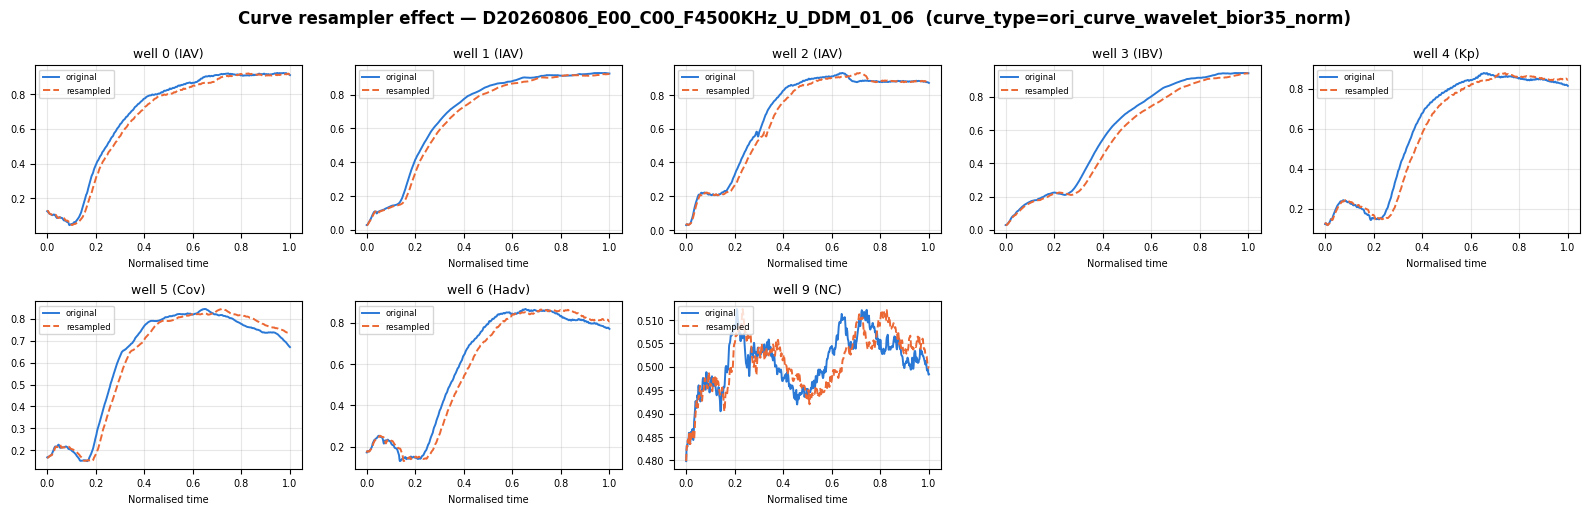

  [*] EXCLUDE_WELL_MAPPING: dropping 3745 samples from wells [6, 7, 8] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07


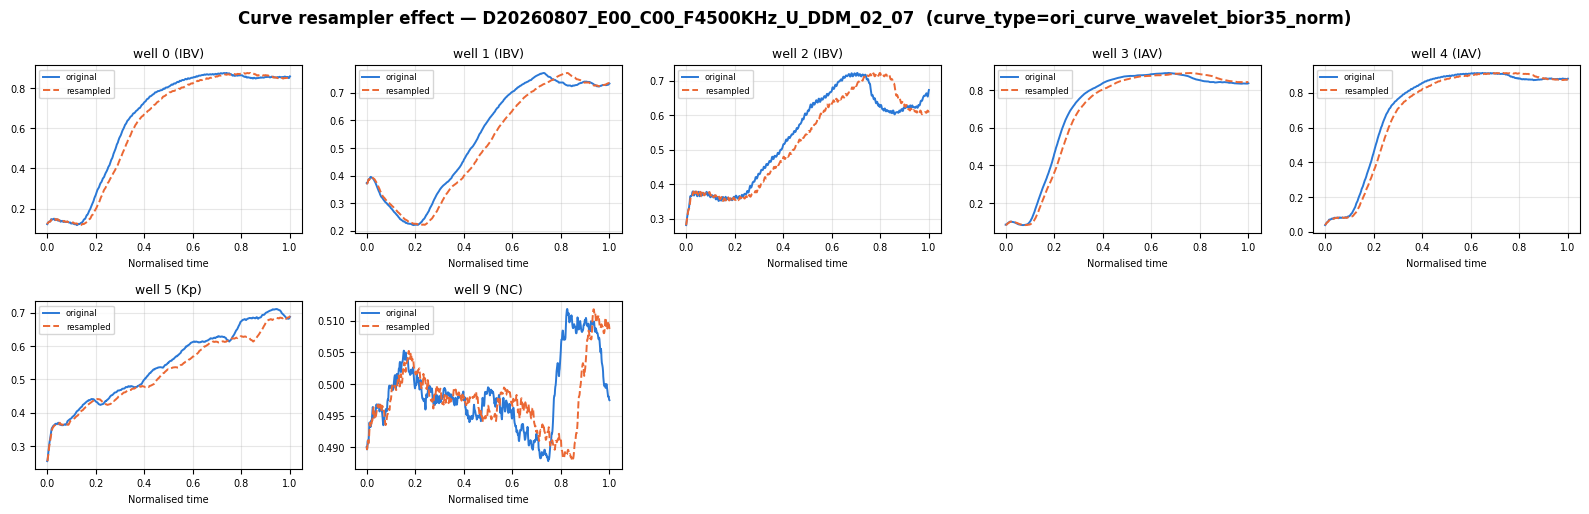

  [*] EXCLUDE_WELL_MAPPING: dropping 1928 samples from wells [6, 8] (y_label={6: 'Cov', 8: 'PC'}, y_concentration={6: '1e+04', 8: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01


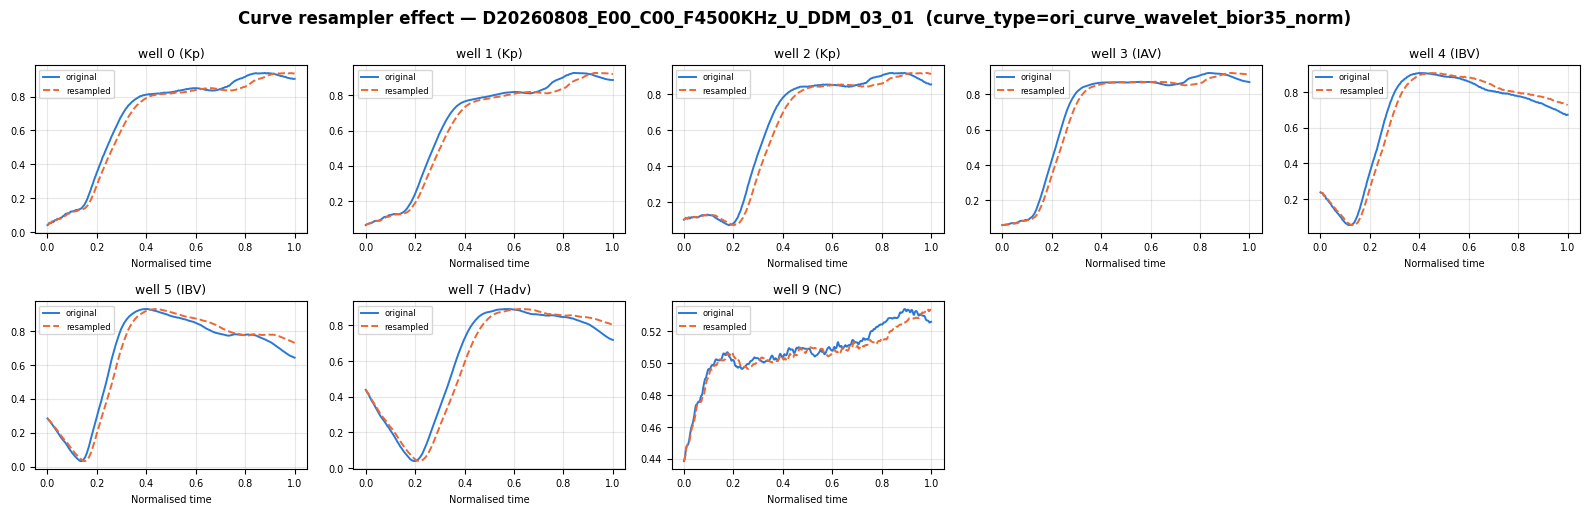

  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01


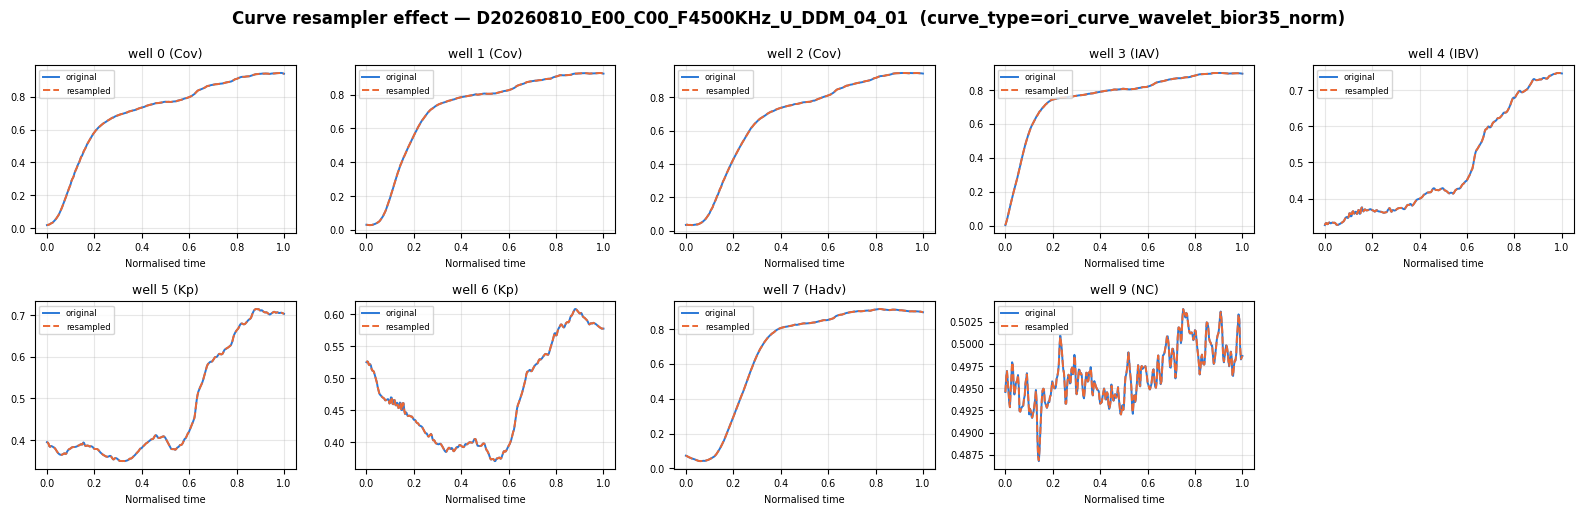

In [18]:
for exp_path in exp_paths:
    plot_resampler_effect_for_exp(exp_path, combined, CURVE_TYPE)


## 9. Attn-recon effect per LOFO fold

Unlike `cnn_gru_dual_cosine_recon` (a **fixed formula** — cosine-similarity-weighted
average of a pixel's spatial neighbours, see `reconstruct_curves_cosine`),
`cnn_gru_dual_attn_recon`'s reconstruction weights are **learned** (`_AttnScores`,
`_WeightedRecon` in `model_utils.py`/`model_utils_mtl.py`) — so each LOFO fold's
independently-trained model has genuinely different attention weights, and running the
*same* raw curves through fold A's vs. fold B's model can produce different
reconstructions. That's why "one figure per LOFO fold" is meaningful here (it wouldn't
be, for the fixed-formula cosine variant — every fold would look identical).

For each fold: one figure, **2 columns** (original mean curve per well | mean curve
after that fold's attn-recon per well) × **1 row per chip**, each subplot overlaying
every well in that chip as a separate line, coloured by class label. Neighbour stacks
are built **per well** (matching `build_neighbor_curve_stack`'s own per-well grouping,
§4) rather than one huge combined-pool stack, to keep peak memory bounded (~10²-10³
pixels × `k+1` × `T` per well, not the whole ~57k-pixel pool at once).

**Note**: uses `ATTN_CURVE_TYPE = "ori_curve_wavelet_bior35_norm"` below, not the
notebook's main `CURVE_TYPE = "ori_curve"` — the actual trained LOFO `attn_recon`
checkpoints on disk (job `272918_1`) only exist for the wavelet/norm variant, so this
section loads its own separate `combined_attn` pool to match.

In [19]:
ATTN_CURVE_TYPE = "ori_curve_wavelet_bior35_norm"   # matches the actual trained LOFO checkpoints
ATTN_MODEL      = "cnn_gru_dual_attn_recon_supcon3"  # default per prior session convention

GROUP_DIR = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME

def short_name(folder):
    return folder.split('_U_', 1)[1]

combined_attn = cdt.combine_group(exp_paths, GROUP_NAME, curve_type=ATTN_CURVE_TYPE)
assert combined_attn is not None, f"combine_group returned None for curve_type={ATTN_CURVE_TYPE}"
assert combined_attn["coords"] is not None and combined_attn["well_ids"] is not None, \
    "No spatial metadata for this curve_type -- attn-recon visualisation needs coords/well_ids."

wells_attn = build_well_table(combined_attn)
print(f"{len(wells_attn)} wells for attn-recon visualisation (curve_type={ATTN_CURVE_TYPE}).")


  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260806_E00_C00_F4500KHz_U_DDM_01_06
  [*] EXCLUDE_WELL_MAPPING: dropping 3745 samples from wells [6, 7, 8] (y_label={6: 'Cov', 7: 'Hadv', 8: 'PC'}, y_concentration={6: '1e+05', 7: '1e+04', 8: '0e+00'}) for D20260807_E00_C00_F4500KHz_U_DDM_02_07
  [*] EXCLUDE_WELL_MAPPING: dropping 1928 samples from wells [6, 8] (y_label={6: 'Cov', 8: 'PC'}, y_concentration={6: '1e+04', 8: '0e+00'}) for D20260808_E00_C00_F4500KHz_U_DDM_03_01
  [*] EXCLUDE_WELL_MAPPING: dropping 0 samples from wells [8] (y_label={8: 'PC'}, y_concentration={8: '0e+00'}) for D20260810_E00_C00_F4500KHz_U_DDM_04_01
  [*] Resampling curves onto common grid: 733 points, duration=2081
32 wells for attn-recon visualisation (curve_type=ori_curve_wavelet_bior35_norm).


In [20]:
def build_recon_extractor(model):
    """Sub-model from the loaded attn_recon model's input up to its reconstruction
    layer's output ((N, 1, T), pre-classifier). Matched by class NAME, not isinstance --
    cnn_gru_dual_attn_recon (model_utils.py) and its _supcon/_mtl variants
    (model_utils_mtl.py, via _build_cnn_gru_dual_attn_recon_embedding_mtl) each define
    their OWN separate _WeightedRecon class object with the same name, so isinstance()
    against a single imported class would silently miss the other module's models."""
    recon_layer = next(l for l in model.layers if type(l).__name__ == "_WeightedRecon")
    return tf.keras.Model(inputs=model.input, outputs=recon_layer.output)


def well_recon_mean(extractor, combined, well_row, k):
    """(mean original curve, mean attn-recon-reconstructed curve) for one well,
    built from a per-well neighbor stack (not the whole pool) to bound memory."""
    idx = well_row["row_idx"]
    curves   = combined["curves"][idx].astype(np.float32)
    coords   = combined["coords"][idx]
    well_ids = combined["well_ids"][idx]
    stack = build_neighbor_curve_stack(curves, coords, well_ids, k=k)
    recon = extractor.predict(stack, batch_size=512, verbose=0)   # (n_pixels, 1, T)
    return curves.mean(axis=0), recon[:, 0, :].mean(axis=0)


print("build_recon_extractor / well_recon_mean defined.")


build_recon_extractor / well_recon_mean defined.


Loading lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06 model...


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 86 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1786611031.649815 1386805 service.cc:145] XLA service 0x54a2b240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786611031.649875 1386805 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
I0000 00:00:1786611033.536765 1386805 device_compiler.h:188] Compiled cluster using XLA!  This li

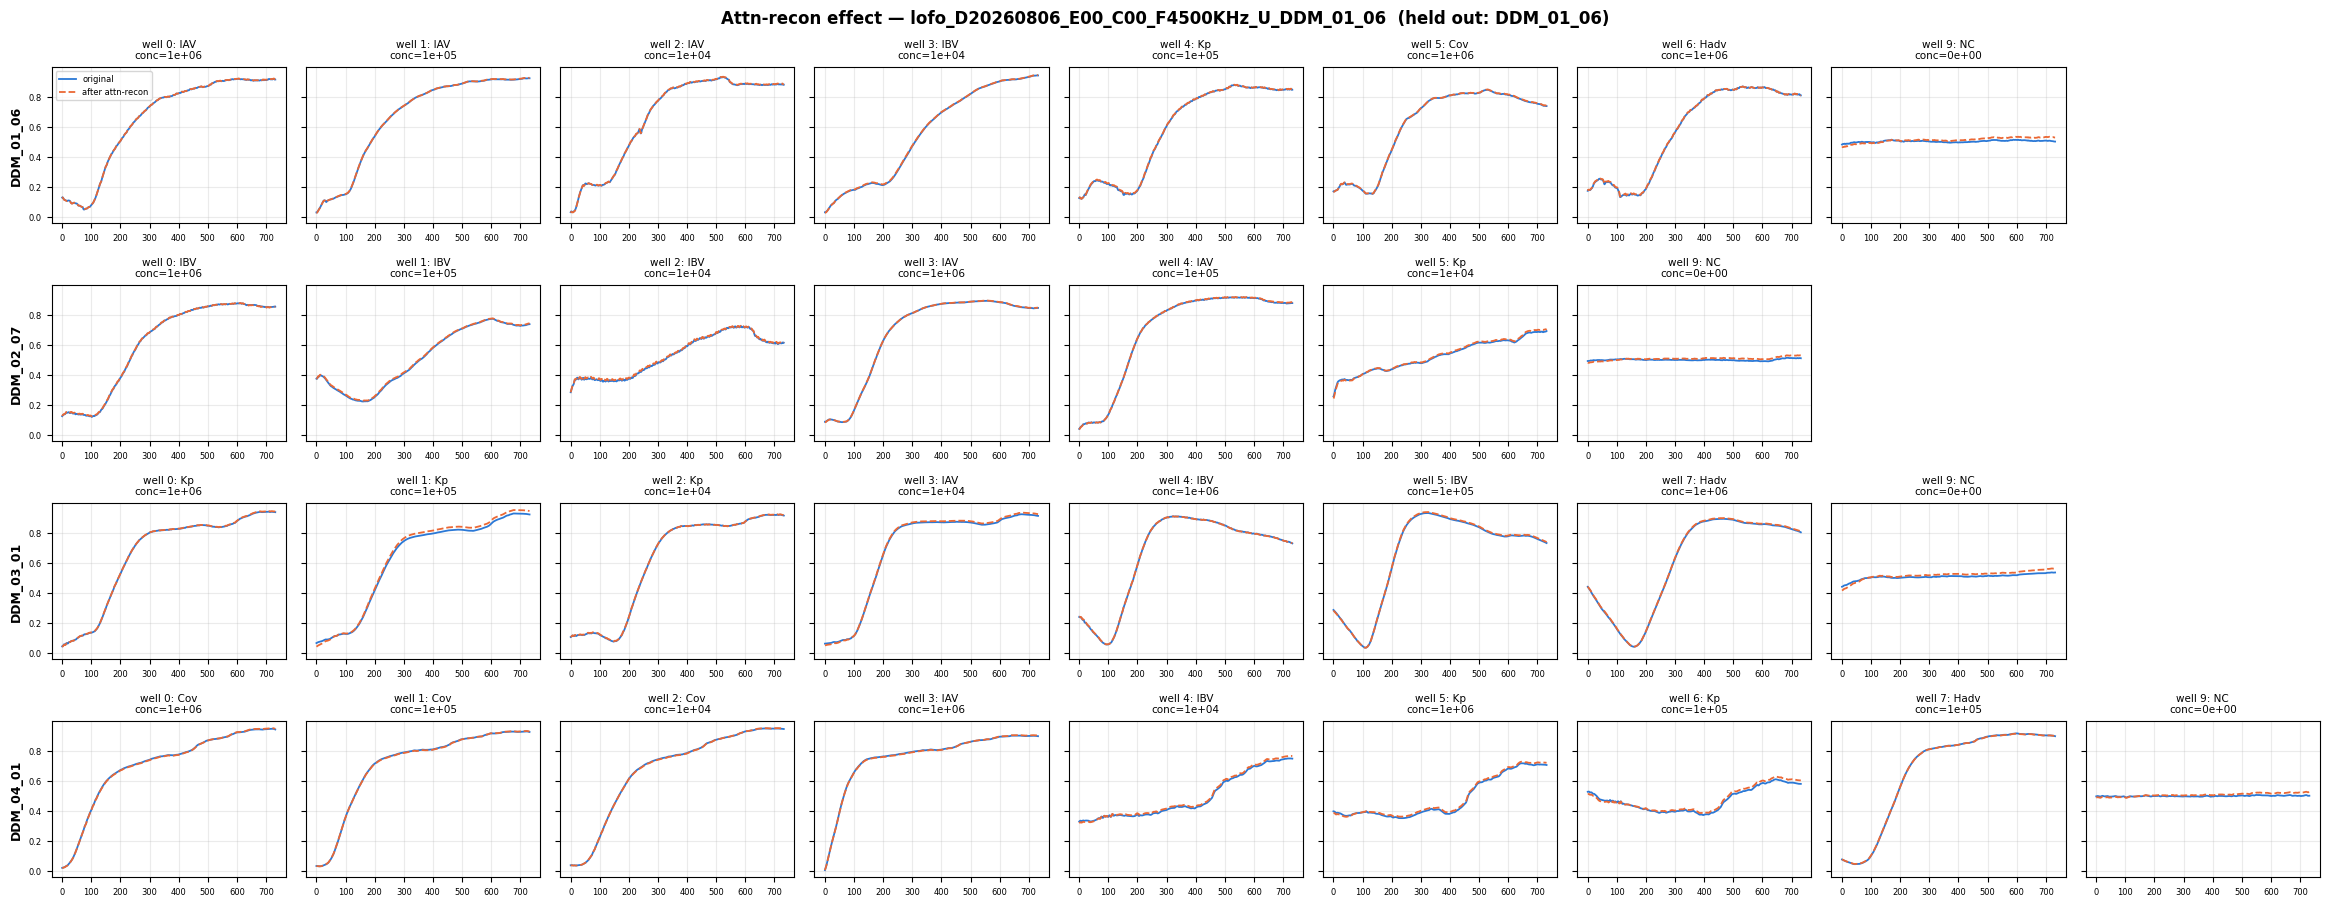

Loading lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07 model...


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 86 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


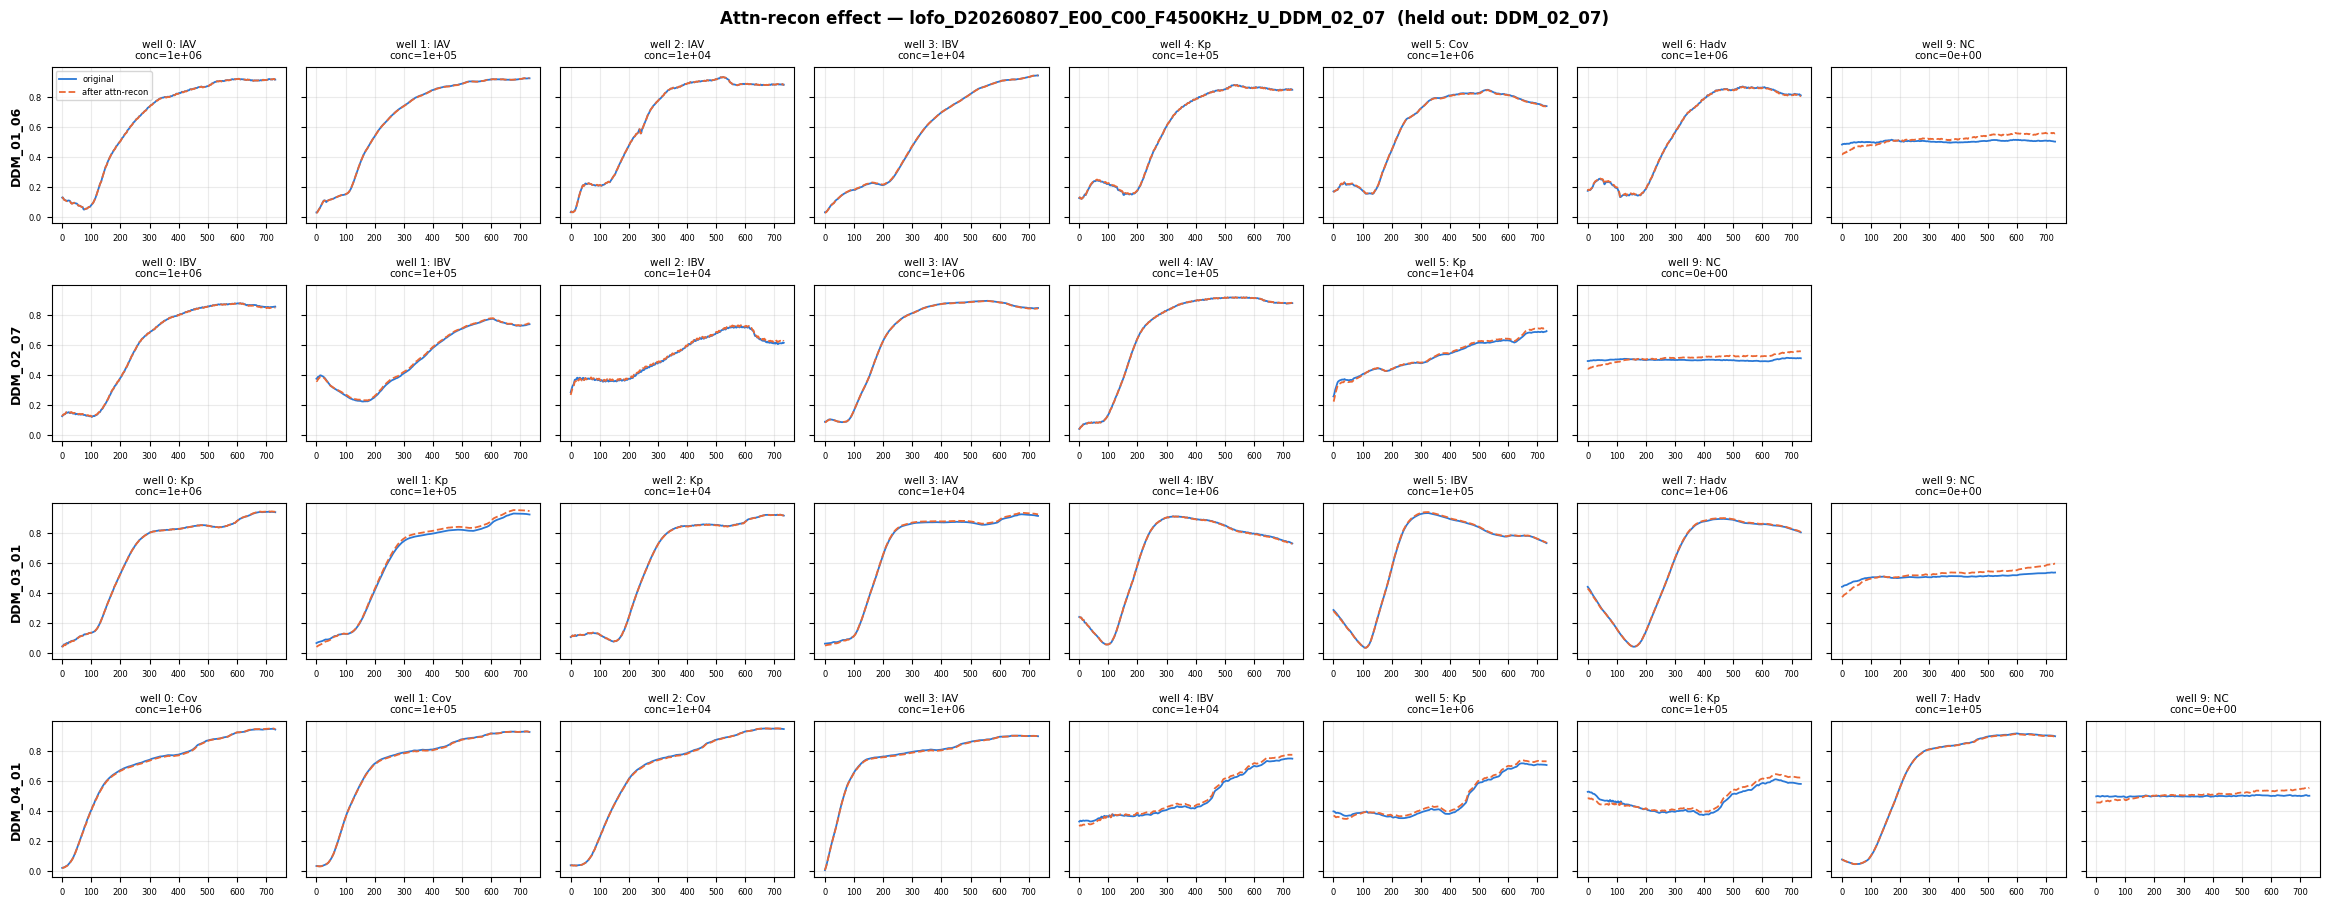

Loading lofo_D20260808_E00_C00_F4500KHz_U_DDM_03_01 model...


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 86 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


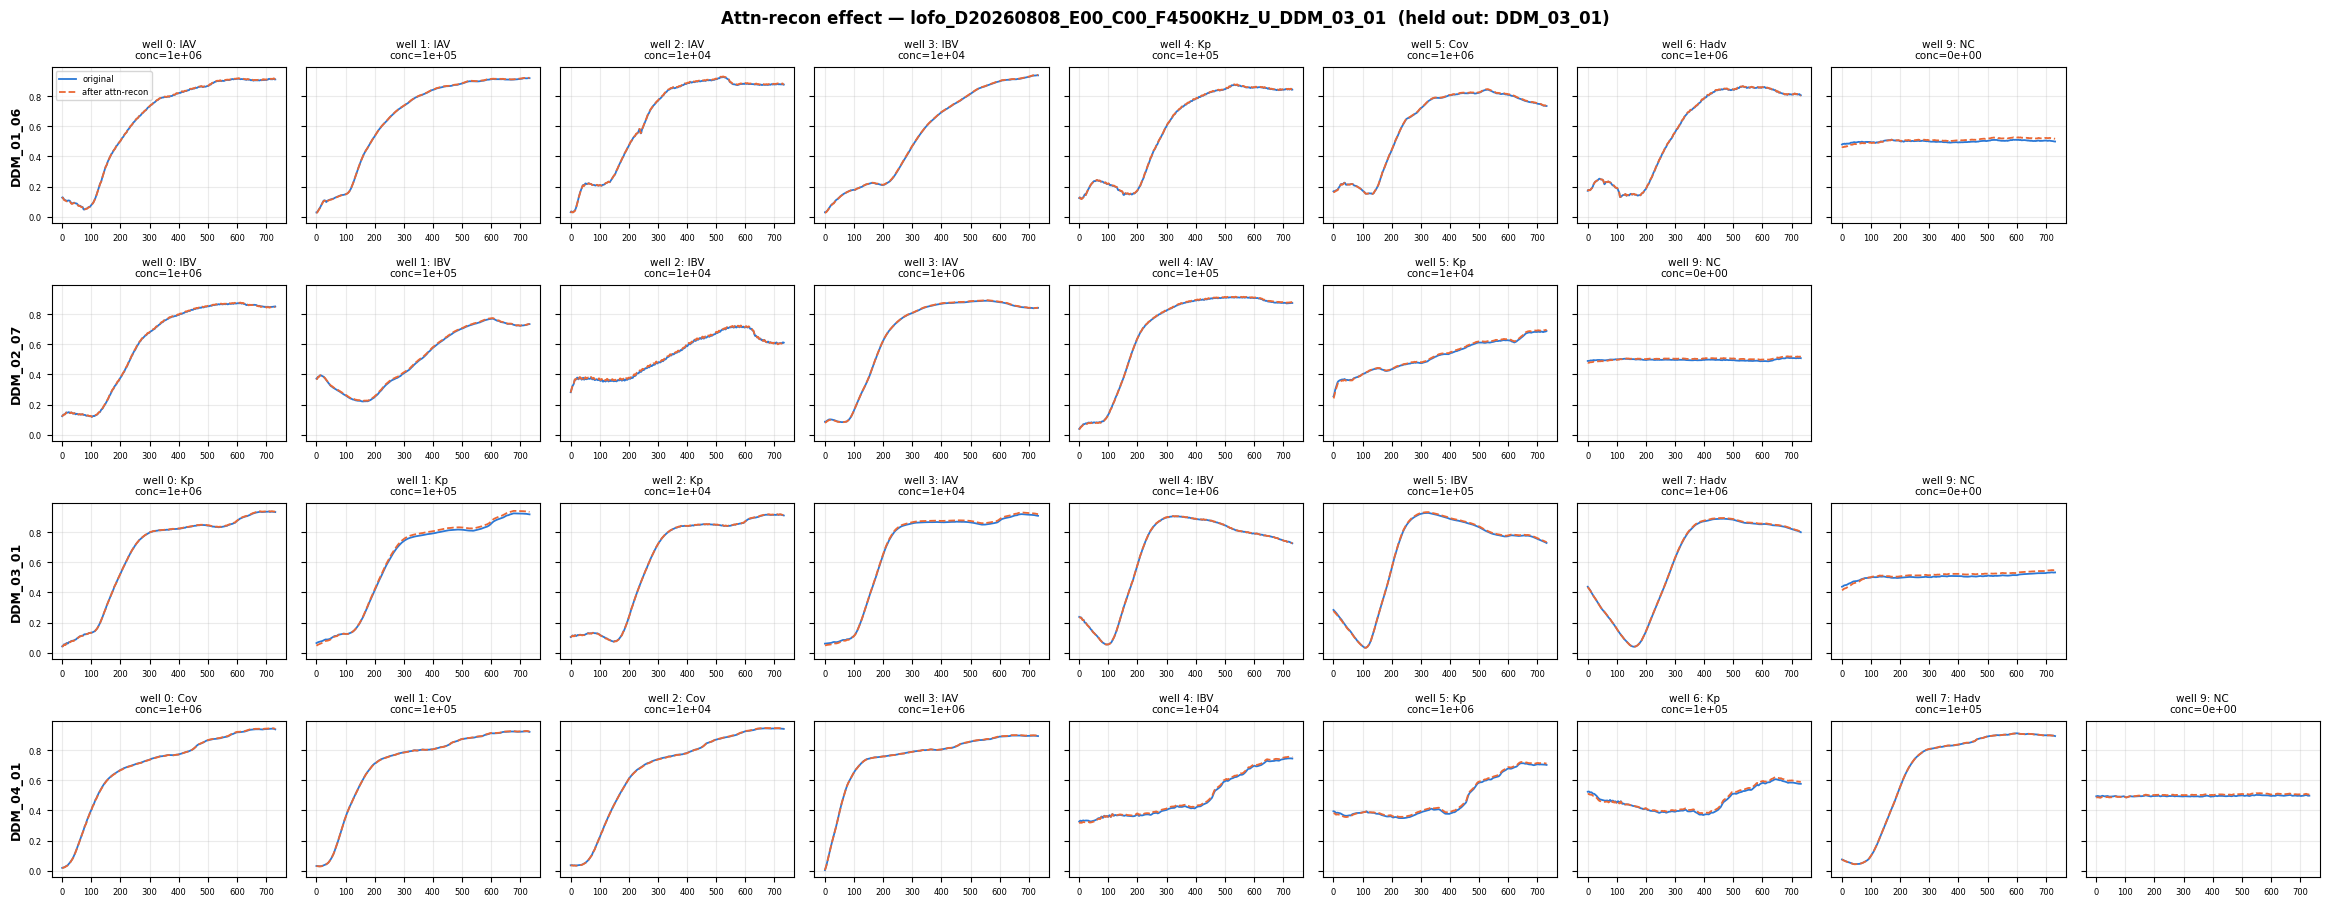

Loading lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01 model...


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 86 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


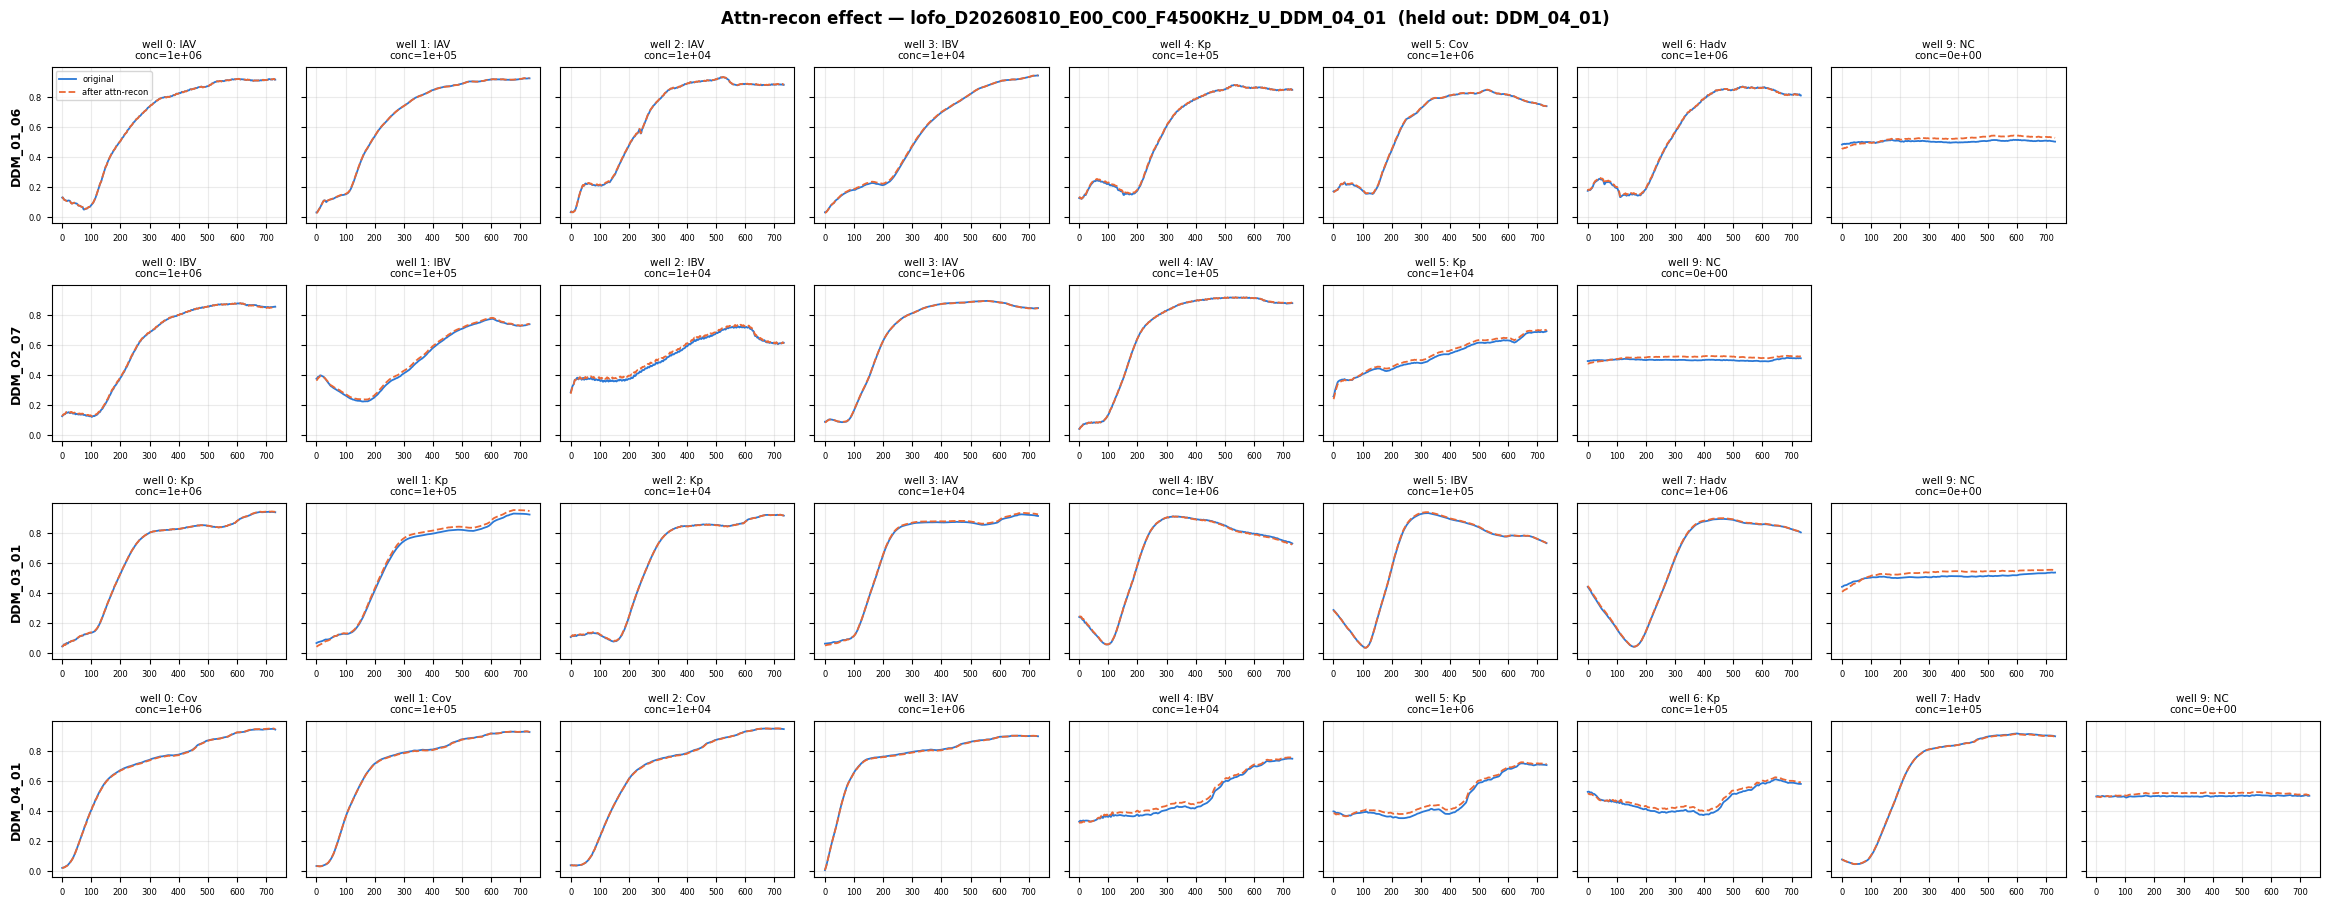

In [21]:
import tensorflow as tf


def well_concentration(combined, well_row):
    """That well's concentration (CONC_MAPPINGS-derived, constant across its pixels),
    1e*-formatted for readability; falls back to the raw value if non-numeric."""
    conc = combined.get("concentration_raw")
    if conc is None:
        return "—"
    val = conc[well_row["row_idx"][0]]
    try:
        return f"{float(val):.0e}"
    except (TypeError, ValueError):
        return str(val) if val not in (None, "") else "—"


max_wells = wells_attn.groupby("dataset_id").size().max()

for fold_label, (_, _) in lofo_splits.items():
    model_path = GROUP_DIR / "model_interpretation" / fold_label / f"{ATTN_MODEL}_None_{ATTN_CURVE_TYPE}_model.keras"
    if not model_path.exists():
        print(f"  [skip] {fold_label}: no trained {ATTN_MODEL} checkpoint at {model_path}")
        continue

    print(f"Loading {fold_label} model...")
    model = tf.keras.models.load_model(model_path)
    extractor = build_recon_extractor(model)

    fig, axes = plt.subplots(len(exp_paths), max_wells,
                             figsize=(2.6 * max_wells, 2.3 * len(exp_paths)), squeeze=False, sharey=True)
    for row_i, exp_path in enumerate(exp_paths):
        chip_wells = wells_attn[wells_attn["dataset_id"] == exp_path.name].sort_values("well_id")
        for col_i in range(max_wells):
            ax = axes[row_i, col_i]
            if col_i >= len(chip_wells):
                ax.axis("off")
                continue
            w = chip_wells.iloc[col_i]
            ori_mean, rec_mean = well_recon_mean(extractor, combined_attn, w, K_NEIGHBORS)
            well_num = w["well_id"].split("::")[-1]
            conc = well_concentration(combined_attn, w)

            ax.plot(ori_mean, color="#2a78d6", lw=1.3, label="original")
            ax.plot(rec_mean, color="#eb6834", lw=1.3, ls="--", label="after attn-recon")
            ax.set_title(f"well {well_num}: {w['label']}\nconc={conc}", fontsize=7.5)
            ax.tick_params(labelsize=6)
            ax.grid(alpha=0.25)
            if row_i == 0 and col_i == 0:
                ax.legend(fontsize=6, loc="upper left")

        axes[row_i, 0].set_ylabel(short_name(exp_path.name), fontsize=9, fontweight="bold")

    held_out = fold_label.replace("lofo_", "", 1)
    fig.suptitle(f"Attn-recon effect — {fold_label}  (held out: {short_name(held_out)})",
                fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()


## 10. Same target across chips

Directly checks the "same target, different shape per chip" domain-shift candidate
from `20260812-lofo_final_4_chip_clean_imbalance_vs_domain_shift.md`'s summary: one
figure, **one subplot per target label**, every well for that label overlaid —
across every chip and concentration — on a single axis.

Parameters mirror `multi_ttp_per_variant_analysis.ipynb`'s `plot_label_conc_grid`
(`_exp_colors`/`_shade`/`_exp_legend`/`label_order`/`figsize_per_cell`/`alpha_indiv`/
`with_all_curves`/`sharey`/`y_scale`), minus the TTP machinery (`method`/`pct`/vlines)
— not needed here. Colour = chip (tab10, one hue per chip, via `_exp_colors`), shade =
concentration within that label (darker = higher, lighter = lower, via `_shade`'s
HLS-lightness nudge — copied verbatim from the reference notebook). Curves are already
on the common resampled time grid (`combined["resampler"].t_grid`), so — unlike §8 —
no x-axis normalisation is needed here; every well is already time-aligned.

In [22]:
import colorsys


def _shade(base_rgb, frac, spread=0.3):
    """Same hue/sat as base_rgb; lightness nudged by frac in [0, 1] (0 = darker/
    higher conc, 1 = lighter/lower conc). Copied verbatim from
    multi_ttp_per_variant_analysis.ipynb's plot_label_conc_grid."""
    h, l, s = colorsys.rgb_to_hls(*base_rgb[:3])
    l = min(0.85, max(0.15, l + (frac - 0.5) * spread))
    return colorsys.hls_to_rgb(h, l, s)


def _exp_colors(exp_names):
    """{chip_name: RGBA} -- consistent tab10 coloring. Copied verbatim from
    multi_ttp_per_variant_analysis.ipynb."""
    cmap_exp = plt.cm.tab10
    return {n: cmap_exp(i % 10) for i, n in enumerate(exp_names)}


def _exp_legend(fig, exp_color, exp_names, y_anchor=-0.02):
    """Adapted from multi_ttp_per_variant_analysis.ipynb's _exp_legend --
    labels shortened via short_name() since our chip names are long folder ids."""
    handles = [plt.Line2D([0], [0], color=exp_color[n], lw=2, label=short_name(n))
               for n in exp_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(exp_names), 4),
               fontsize=8, bbox_to_anchor=(0.5, y_anchor), frameon=True)


def _raw_conc(combined, well_row):
    """Numeric concentration for one well (for sort/shade ordering) -- None if
    missing/non-numeric. See well_concentration (§9) for the display-string version."""
    conc = combined.get("concentration_raw")
    if conc is None:
        return None
    val = conc[well_row["row_idx"][0]]
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


print("_shade / _exp_colors / _exp_legend / _raw_conc defined.")


_shade / _exp_colors / _exp_legend / _raw_conc defined.


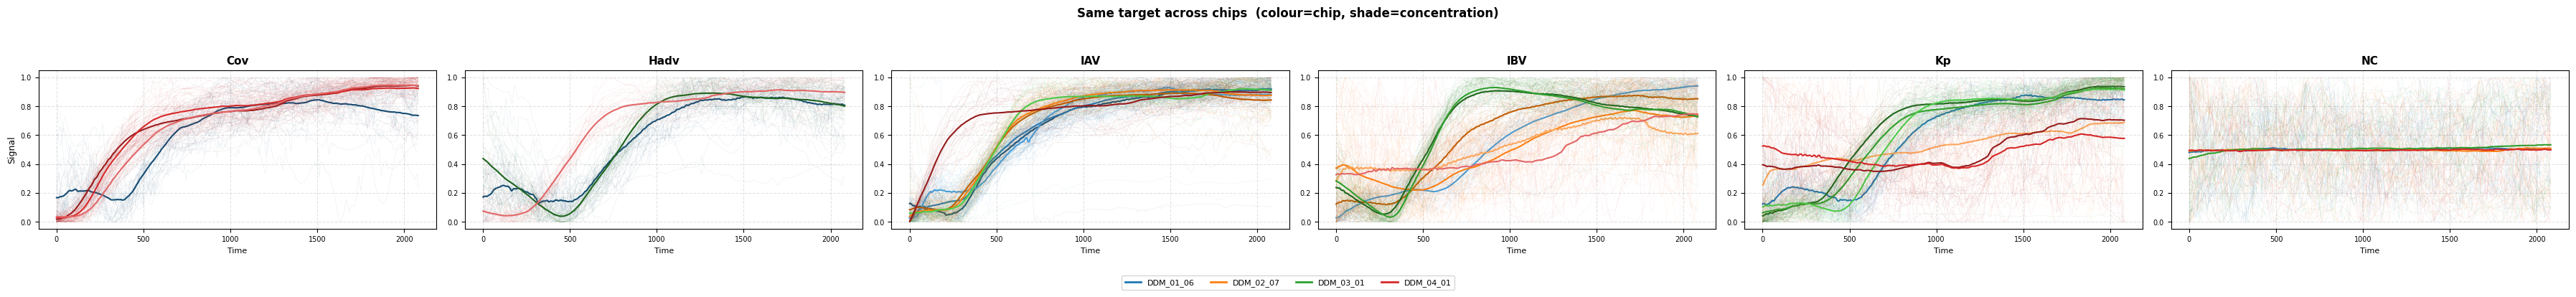

In [37]:
def plot_target_across_chips(
    combined,
    label_order=None,
    figsize_per_cell=(6, 4),
    title=None,
    alpha_indiv=0.10,
    with_all_curves=True,
    sharey=False,
    y_scale=None,
    conc_colour=True
):
    """1 figure, 1 subplot per target label -- every well for that label, across
    every chip and concentration, overlaid on one axis. Colour = chip, shade =
    concentration within that label (darker = higher). No TTP/vlines (unlike
    plot_label_conc_grid, which this is adapted from)."""
    wells = build_well_table(combined)
    exp_names = sorted(wells["dataset_id"].unique())
    exp_color = _exp_colors(exp_names)

    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen]
        all_labels += [l for l in labels_seen if l not in all_labels]
    else:
        nc    = [l for l in labels_seen if str(l).startswith("NC")]
        nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(all_labels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]),
                             squeeze=False, sharey="row" if sharey else False)
    axes = axes[0]

    for ax, label in zip(axes, all_labels):
        label_wells = wells[wells["label"] == label].copy()
        label_wells["_conc"] = [_raw_conc(combined, w) for _, w in label_wells.iterrows()]
        concs_sorted = sorted({c for c in label_wells["_conc"] if c is not None})
        n_concs = len(concs_sorted)

        for _, w in label_wells.iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]
            mean = curves.mean(axis=0)
            conc = w["_conc"]
            frac = (concs_sorted.index(conc) / (n_concs - 1)) if (conc is not None and n_concs > 1) else 0.5
            if(conc_colour):
                color = _shade(exp_color[w["dataset_id"]], 1 - frac)
            else:
                color = exp_color[w["dataset_id"]]

            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.5)

        ax.set_title(str(label), fontsize=11, fontweight="bold")
        ax.set_xlabel("Time", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if y_scale is not None:
            ax.set_ylim(*y_scale)

    axes[0].set_ylabel("Signal", fontsize=9)
    fig.suptitle(title or "Same target across chips  (colour=chip, shade=concentration)",
                fontsize=12, fontweight="bold")
    _exp_legend(fig, exp_color, exp_names)
    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()


plot_target_across_chips(combined)


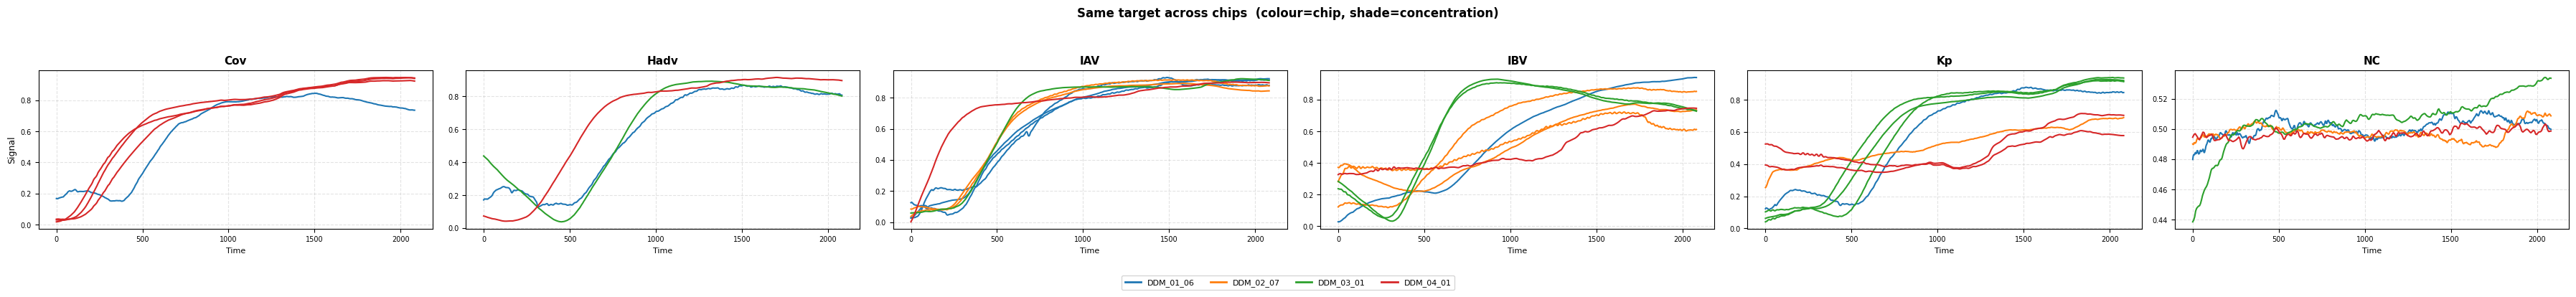

In [38]:
plot_target_across_chips(combined, with_all_curves=False, conc_colour=False)

## 11. Finding different targets that look too similar across chips

**Question**: not just "does target X drift across chips" (§10, visual), but "does
that drift make two *different* targets harder to tell apart than the *same* target
across chips" — the actual failure mode implied by the brainstorming doc's §3 finding
(models losing to the majority-class baseline = learning chip-specific shortcuts, not
target-discriminative shape).

**Approach — two complementary, cheap checks, both on the existing 32-well pool** (no
new data, no TTP-specific pipeline needed — reuses `combined["features_df"]["Ct"]`,
already computed by `02_outlier_detection_pipeline.py`'s kinetic-feature extraction,
as the TTP-ish scalar):

1. **PCA embedding, coloured by label, shaped by chip.** Standardize each well's
   [mean curve ++ mean `Ct`] feature vector, project to 2D. If the same-coloured
   (same-label) points cluster together *regardless of marker shape (chip)*, target
   signal dominates — good. If points instead cluster by *marker shape* (chip)
   irrespective of colour, chip identity dominates over target signal — the domain
   -shift signature, visually.
2. **Nearest cross-chip-neighbour label match.** For each well, find its nearest
   neighbour (same feature space/distance) *restricted to other chips* — quantifies
   #1: the fraction of wells whose nearest cross-chip neighbour has a **different**
   label is a direct, numeric "cross-chip target confusability" score, and the
   per-well table pinpoints exactly *which* target pairs get confused.

Both use the same standardized feature vector, so they're consistent with each other
— #1 for the visual gestalt, #2 for a number you can track/threshold on.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def build_well_feature_matrix(combined, ct_col="Ct"):
    """Per-well [mean curve ++ mean Ct], standardized (zero mean, unit variance
    per feature dimension) so curve amplitude and the Ct scalar contribute on a
    comparable scale -- avoids one dimension silently dominating distance/PCA."""
    wells = build_well_table(combined)
    curves_mean = np.stack([combined["curves"][idx].mean(axis=0) for idx in wells["row_idx"]])

    feats = [curves_mean]
    if ct_col in combined["features_df"].columns:
        ct_vals = np.array([combined["features_df"][ct_col].values[idx].mean()
                            for idx in wells["row_idx"]])
        if np.isfinite(ct_vals).all():
            feats.append(ct_vals[:, None])
        else:
            print(f"  [!] '{ct_col}' has non-finite values for some wells -- dropping it "
                  f"from the feature vector (curve shape only).")
    else:
        print(f"  [!] '{ct_col}' not in features_df -- using curve shape only.")

    X_raw = np.concatenate(feats, axis=1)
    X = StandardScaler().fit_transform(X_raw)
    return wells, X


wells_feat, X_feat = build_well_feature_matrix(combined)
print(f"Feature matrix: {X_feat.shape} ({X_feat.shape[1] - 1} curve dims + 1 Ct dim), "
      f"{len(wells_feat)} wells.")


  [!] 'Ct' has non-finite values for some wells -- dropping it from the feature vector (curve shape only).
Feature matrix: (32, 733) (732 curve dims + 1 Ct dim), 32 wells.


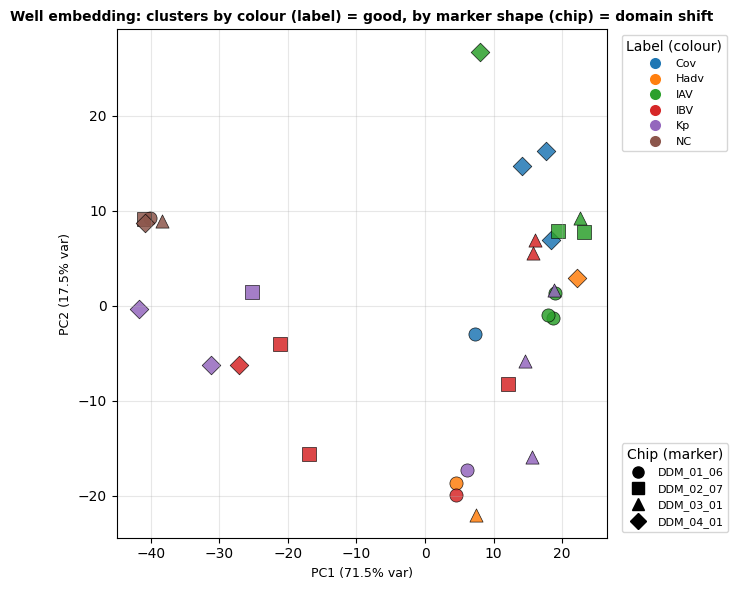

In [25]:
# ── 1. PCA embedding: colour = label, marker = chip ────────────────────────────
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_feat)

all_labels = sorted(wells_feat["label"].unique())
label_color = {lbl: plt.cm.tab10(i % 10) for i, lbl in enumerate(all_labels)}
all_chips = sorted(wells_feat["dataset_id"].unique())
chip_marker = {c: m for c, m in zip(all_chips, ["o", "s", "^", "D", "v", "P"])}

fig, ax = plt.subplots(figsize=(7, 6))
for (label, chip), grp in wells_feat.assign(_pc1=X_pca[:, 0], _pc2=X_pca[:, 1]).groupby(["label", "dataset_id"]):
    ax.scatter(grp["_pc1"], grp["_pc2"], color=label_color[label], marker=chip_marker[chip],
              s=90, edgecolor="black", linewidth=0.5, alpha=0.85)

label_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=label_color[l],
                            markersize=9, label=l) for l in all_labels]
chip_handles = [plt.Line2D([0], [0], marker=chip_marker[c], color="black", linestyle="",
                           markersize=8, label=short_name(c)) for c in all_chips]
leg1 = ax.legend(handles=label_handles, title="Label (colour)", loc="upper left",
                 bbox_to_anchor=(1.02, 1), fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=chip_handles, title="Chip (marker)", loc="lower left",
         bbox_to_anchor=(1.02, 0), fontsize=8)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=9)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=9)
ax.set_title("Well embedding: clusters by colour (label) = good, by marker shape (chip) = domain shift",
            fontsize=10, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
# ── 2. Nearest cross-chip-neighbour label match ─────────────────────────────────
def nearest_cross_chip_neighbor(wells_feat, X):
    """For each well, its nearest neighbour (Euclidean, in the standardized
    curve+Ct space) among wells from OTHER chips only -- and whether that
    neighbour shares the same label. self_idx/nn_idx are positional indices into
    wells_feat/X, kept so callers can look up the actual curves later."""
    dist = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1)
    rows = []
    for i in range(len(wells_feat)):
        same_chip = (wells_feat["dataset_id"].values == wells_feat["dataset_id"].values[i])
        d = dist[i].copy()
        d[same_chip] = np.inf   # exclude self and same-chip wells
        j = int(np.argmin(d))
        rows.append({
            "self_idx": i, "nn_idx": j,
            "chip": short_name(wells_feat["dataset_id"].values[i]),
            "label": wells_feat["label"].values[i],
            "nn_chip": short_name(wells_feat["dataset_id"].values[j]),
            "nn_label": wells_feat["label"].values[j],
            "same_label": wells_feat["label"].values[i] == wells_feat["label"].values[j],
            "distance": float(d[j]),
        })
    return pd.DataFrame(rows)


nn_df = nearest_cross_chip_neighbor(wells_feat, X_feat)
mismatch_rate = 1 - nn_df["same_label"].mean()
print(f"Cross-chip target confusability: {mismatch_rate*100:.1f}% of wells' nearest "
      f"neighbour on a DIFFERENT chip has a DIFFERENT label "
      f"({(~nn_df['same_label']).sum()}/{len(nn_df)} wells).")
print()
print("Confused pairs (nearest cross-chip neighbour has a different label), by distance:")
nn_df[~nn_df["same_label"]].sort_values("distance")


Cross-chip target confusability: 53.1% of wells' nearest neighbour on a DIFFERENT chip has a DIFFERENT label (17/32 wells).

Confused pairs (nearest cross-chip neighbour has a different label), by distance:


,self_idx,nn_idx,chip,label,nn_chip,nn_label,same_label,distance
30,30,15,DDM_04_01,Hadv,DDM_03_01,Kp,False,6.263451
15,15,30,DDM_03_01,Kp,DDM_04_01,Hadv,False,6.263451
1,1,15,DDM_01_06,IAV,DDM_03_01,Kp,False,6.576637
0,0,30,DDM_01_06,IAV,DDM_04_01,Hadv,False,6.983514
8,8,16,DDM_02_07,IBV,DDM_03_01,Kp,False,7.539259
16,16,8,DDM_03_01,Kp,DDM_02_07,IBV,False,7.539259
25,25,1,DDM_04_01,Cov,DDM_01_06,IAV,False,8.503135
5,5,8,DDM_01_06,Cov,DDM_02_07,IBV,False,10.447527
2,2,15,DDM_01_06,IAV,DDM_03_01,Kp,False,10.722154
17,17,8,DDM_03_01,Kp,DDM_02_07,IBV,False,11.109070


### Curves for the most confusable pairs

The 9 closest (self, nearest-cross-chip-neighbour) mismatched pairs from the table
above, spelled out as curves: each panel overlays one well's mean curve against its
nearest neighbour's mean curve from a *different chip and different label* — this is
literally why those two wells sit next to each other in feature space despite being
different targets.

In [27]:
mismatched = nn_df[~nn_df["same_label"]].sort_values("distance")
mismatched = mismatched[(mismatched['label'] != "NC") & (mismatched['nn_label'] != "NC")].sort_values("distance").head(9)
mismatched

,self_idx,nn_idx,chip,label,nn_chip,nn_label,same_label,distance
30,30,15,DDM_04_01,Hadv,DDM_03_01,Kp,False,6.263451
15,15,30,DDM_03_01,Kp,DDM_04_01,Hadv,False,6.263451
1,1,15,DDM_01_06,IAV,DDM_03_01,Kp,False,6.576637
0,0,30,DDM_01_06,IAV,DDM_04_01,Hadv,False,6.983514
8,8,16,DDM_02_07,IBV,DDM_03_01,Kp,False,7.539259
16,16,8,DDM_03_01,Kp,DDM_02_07,IBV,False,7.539259
25,25,1,DDM_04_01,Cov,DDM_01_06,IAV,False,8.503135
5,5,8,DDM_01_06,Cov,DDM_02_07,IBV,False,10.447527
2,2,15,DDM_01_06,IAV,DDM_03_01,Kp,False,10.722154


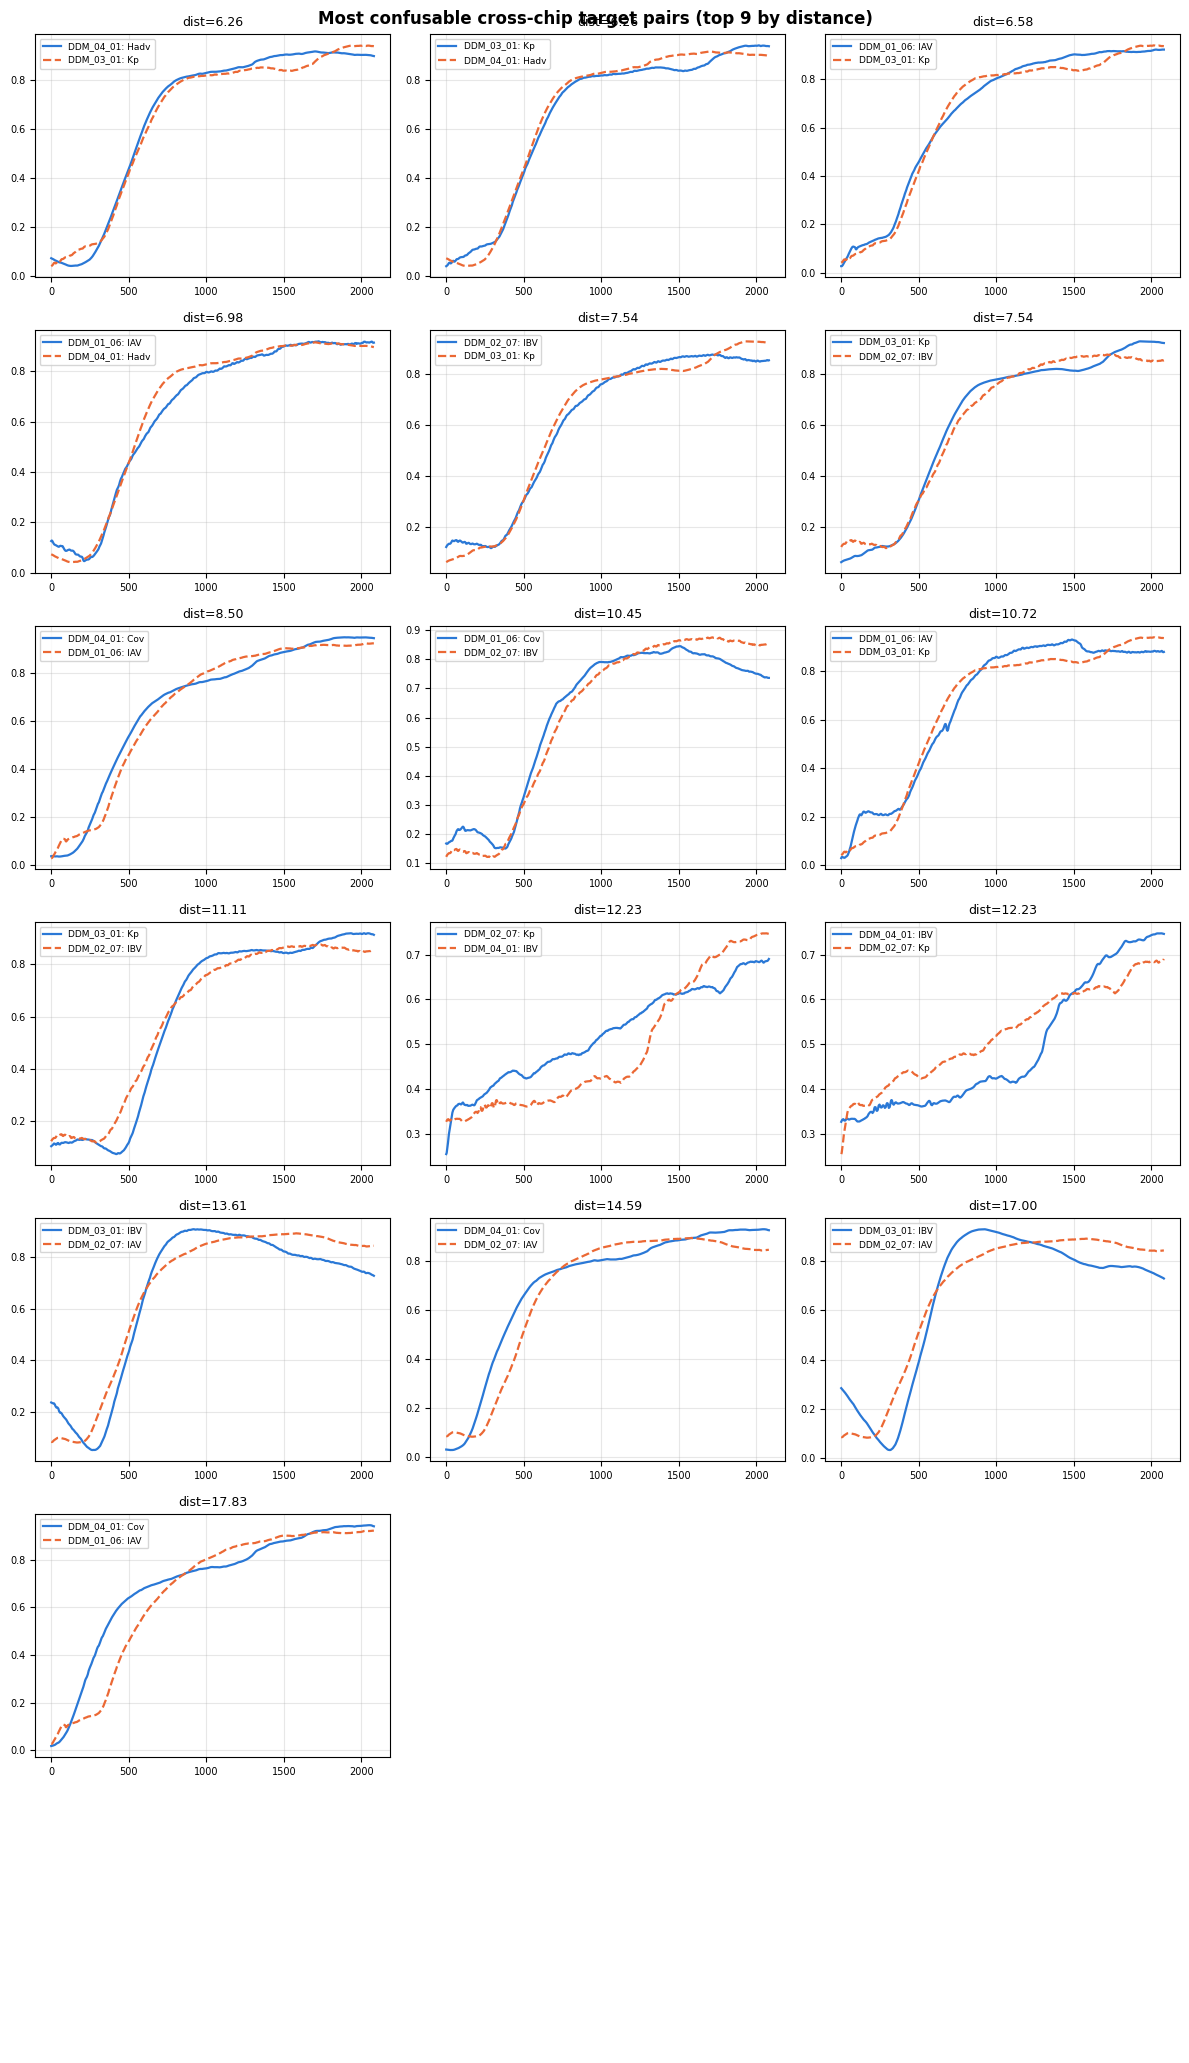

In [28]:
mismatched = nn_df[~nn_df["same_label"]].sort_values("distance")
mismatched = mismatched[(mismatched['label'] != "NC") & (mismatched['nn_label'] != "NC")].sort_values("distance").head(21)

ncols = 3
nrows = 7
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
t = np.asarray(combined["resampler"].t_grid, dtype=float)

for k in range(nrows * ncols):
    ax = axes[k // ncols, k % ncols]
    if k >= len(mismatched):
        ax.axis("off")
        continue
    row = mismatched.iloc[k]
    self_well = wells_feat.iloc[row["self_idx"]]
    nn_well   = wells_feat.iloc[row["nn_idx"]]
    self_mean = combined["curves"][self_well["row_idx"]].mean(axis=0)
    nn_mean   = combined["curves"][nn_well["row_idx"]].mean(axis=0)

    ax.plot(t, self_mean, color="#2a78d6", lw=1.6, label=f'{row["chip"]}: {row["label"]}')
    ax.plot(t, nn_mean, color="#eb6834", lw=1.6, ls="--", label=f'{row["nn_chip"]}: {row["nn_label"]}')
    ax.set_title(f'dist={row["distance"]:.2f}', fontsize=9)
    ax.legend(fontsize=6.5, loc="upper left")
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

fig.suptitle("Most confusable cross-chip target pairs (top 9 by distance)",
            fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 12. LOFO fold accuracy by model

Same grouped-bar chart as `kfold5_cross_chip_summary.ipynb`'s `plot_fold_accuracy_by_model`
(x=fold, one sub-bar per model, y=accuracy%), applied to this group's **LOFO** results
instead of kfold5 — the actual held-out-chip accuracies behind the numbers referenced
throughout this notebook (worst-imbalance-fold in §3/§6) and the brainstorming doc's
12-36% collapse. Uses `ATTN_CURVE_TYPE`/`GROUP_DIR` (§9), since that's the curve type
with real trained LOFO results on disk, and reuses `lofo_splits` (§3) for the fold set
— fold membership is curve-type-independent (built from `dataset_id`, not curves).

In [29]:
import joblib
from sklearn.metrics import accuracy_score

b06 = importlib.import_module("06b_cross_dataset_prediction_report")
SC3_MODELS = ["cnn_gru_dual_supcon3", "cnn_gru_dual_attn_recon_supcon3"]

legacy_lofo_path = b06.find_results_path(GROUP_DIR, "lofo", ATTN_CURVE_TYPE)
lofo_results_full = b06.load_partitioned(GROUP_DIR, "lofo", ATTN_CURVE_TYPE, legacy_path=legacy_lofo_path)
assert lofo_results_full, f"No LOFO results found for {GROUP_NAME}/{ATTN_CURVE_TYPE}"
print(f"Loaded LOFO results for {GROUP_NAME}/{ATTN_CURVE_TYPE}")

lofo_fold_labels = sorted(lofo_splits.keys())

rows = []
for fold in lofo_fold_labels:
    res_entry = lofo_results_full.get(fold, {}).get(None)   # outlier_filter=None (Baseline)
    if res_entry is None:
        continue
    for m in SC3_MODELS:
        preds_key, probs_key, _ = config.MODEL_KEY_MAP[m]
        if preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        rows.append({"fold": fold, "model": m,
                     "accuracy": accuracy_score(y_true, y_pred) * 100,
                     "n_test": len(y_true)})

lofo_acc_df = pd.DataFrame(rows)
lofo_acc_df


Loading: /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final_nc_subtract/cross_dataset_cv/final_4_chip_clean/cross_dataset_classification_performances_lofo_ori_curve_wavelet_bior35_norm.joblib


,fold,model,accuracy,n_test
0,lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06,cnn_gru_dual_supcon3,35.913697,14507
1,lofo_D20260806_E00_C00_F4500KHz_U_DDM_01_06,cnn_gru_dual_attn_recon_supcon3,19.721514,14507
2,lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07,cnn_gru_dual_supcon3,31.794433,11675
3,lofo_D20260807_E00_C00_F4500KHz_U_DDM_02_07,cnn_gru_dual_attn_recon_supcon3,26.492505,11675
4,lofo_D20260808_E00_C00_F4500KHz_U_DDM_03_01,cnn_gru_dual_supcon3,24.058090,14598
5,lofo_D20260808_E00_C00_F4500KHz_U_DDM_03_01,cnn_gru_dual_attn_recon_supcon3,24.674613,14598
6,lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01,cnn_gru_dual_supcon3,11.922973,18435
7,lofo_D20260810_E00_C00_F4500KHz_U_DDM_04_01,cnn_gru_dual_attn_recon_supcon3,15.296989,18435


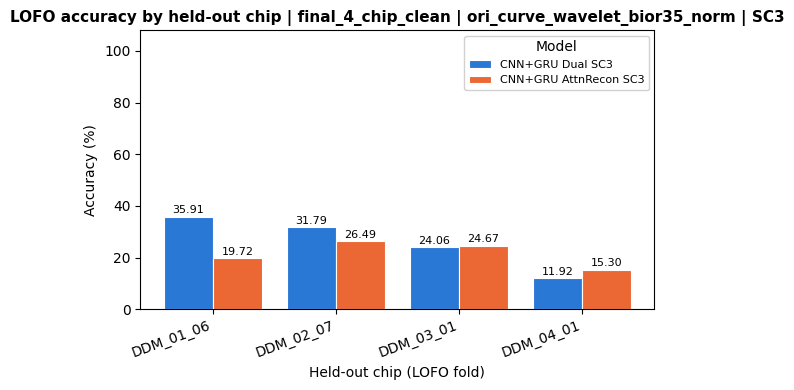


Mean ± std across folds:
                                  mean    std
model                                        
cnn_gru_dual_attn_recon_supcon3  21.55   5.05
cnn_gru_dual_supcon3             25.92  10.55


In [34]:
%matplotlib inline
def plot_fold_accuracy_by_model(acc_df, fold_labels, models, title, xtick_labels=None, figsize=(6, 4)):
    """Grouped bar chart: x=fold, one sub-bar per model, y=accuracy%. Identical to
    kfold5_cross_chip_summary.ipynb's plot_fold_accuracy_by_model, plus an optional
    xtick_labels override so long 'lofo_<chip>' keys can be shortened for display
    without touching the acc_df lookup keys."""
    if xtick_labels is None:
        xtick_labels = fold_labels
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(fold_labels))

    palette = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
               '#e87ba4', '#008300', '#4a3aa7', '#e34948']

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        sub = acc_df[acc_df.model == model].set_index("fold")
        ys = np.array([sub["accuracy"].get(f, np.nan) for f in fold_labels])
        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
               color=palette[mi % len(palette)],
               label=config.MODEL_PRINT_MAP.get(model, model),
               edgecolor='white', linewidth=0.8)
        for xi, yi in zip(x + offset, ys):
            if not np.isnan(yi):
                ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, rotation=20, ha="right")
    ax.set_xlabel('Held-out chip (LOFO fold)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 108)
    ax.legend(title='Model', fontsize=8, loc='best', framealpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    fig.tight_layout()
    plt.show()


fold_display = [short_name(f.replace("lofo_", "", 1)) for f in lofo_fold_labels]
plot_fold_accuracy_by_model(
    lofo_acc_df, lofo_fold_labels, SC3_MODELS,
    title=f"LOFO accuracy by held-out chip | {GROUP_NAME} | {ATTN_CURVE_TYPE} | SC3",
    xtick_labels=fold_display,
)

print("\nMean ± std across folds:")
print(lofo_acc_df.groupby("model")["accuracy"].agg(["mean", "std"]).round(2))


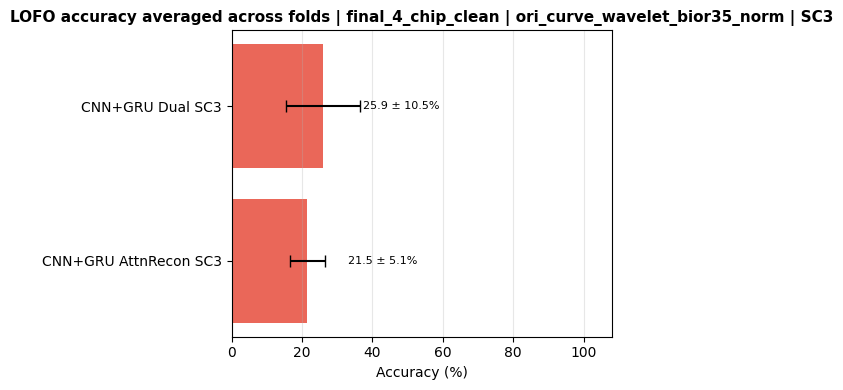

In [35]:
def plot_avg_accuracy_by_model(acc_df, title, figsize=(6, 4)):
    """Horizontal bar chart: one bar per model, averaged across every LOFO fold,
    with ±std error bars. Mirrors 06_model_prediction_report.py's
    render_overview_chart (accuracy-tier colouring, value labels)."""
    summary = acc_df.groupby("model")["accuracy"].agg(["mean", "std"]).reset_index()
    summary["name"] = summary["model"].map(lambda m: config.MODEL_PRINT_MAP.get(m, m))
    summary = summary.sort_values("mean")

    names = summary["name"].tolist()
    means = summary["mean"].to_numpy()
    stds  = summary["std"].fillna(0).to_numpy()

    colors = ["#27ae60" if a >= 80 else "#e67e22" if a >= 60 else "#e74c3c" for a in means]
    fig, ax = plt.subplots(figsize=(figsize[0], max(figsize[1], 0.55 * len(names))))
    bars = ax.barh(names, means, xerr=stds, color=colors, alpha=0.85, capsize=4,
                   error_kw={"elinewidth": 1.5})

    max_std = max(stds) if len(stds) else 0
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_width() + max_std + 1, bar.get_y() + bar.get_height() / 2,
                f"{m:.1f} ± {s:.1f}%", va="center", fontsize=8)

    ax.set_xlabel("Accuracy (%)", fontsize=10)
    ax.set_xlim(0, max(108, means.max() + max_std + 15))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_avg_accuracy_by_model(
    lofo_acc_df,
    title=f"LOFO accuracy averaged across folds | {GROUP_NAME} | {ATTN_CURVE_TYPE} | SC3",
)
